## Conditional Mean Models for UK 10-Year Gilt Yields

This notebook is the third stage of the gilt-yield time-series project. It moves from exploratory diagnostics to formal **conditional-mean modelling**.

The notebook is organised into six model families:

1. **Random Walk**
2. **Autoregressive (AR)**
3. **Moving Average (MA)**
4. **Autoregressive Moving Average (ARMA)**
5. **Autoregressive Integrated Moving Average (ARIMA)**
6. **Seasonal ARIMA (SARIMA)**


Notebook 02 established that:

- the **10-year yield level is non-stationary**;
- first differencing removes most of the persistence in the level;
- the daily-change series has little linear autocorrelation in its ACF/PACF;

Therefore:

- **AR, MA and ARMA** models are fitted to daily yield changes in basis points;
- **ARIMA and SARIMA** are fitted to the yield level with non-seasonal differencing handled inside the model;
- the **Random Walk** is retained as the core benchmark.

All model development and validation is restricted to observations before **23 September 2022**. The final exercise forecasts the crisis period from a fixed pre-crisis origin to form a no-crisis statistical baseline.


### Import packages

In [1]:
from pathlib import Path
from itertools import product
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import normaltest

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

%matplotlib inline

### Load the processed dataset

Notebook 03 depends on the cleaned output from Notebook 01.

In [2]:
DATA_PATH = Path("data") / "processed" / "boe_10y_zero_coupon_clean.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run Notebook 01 first so that "
        "data/processed/boe_10y_zero_coupon_clean.csv is created."
    )

boe = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

required_columns = {"date", "yield_10y"}

if not required_columns.issubset(boe.columns):
    raise ValueError(
        f"Expected columns {required_columns}, but found {set(boe.columns)}"
    )

boe = (
    boe
    .sort_values("date")
    .drop_duplicates(subset="date")
    .reset_index(drop=True)
)

print(f"Loaded: {DATA_PATH}")
print(f"Observations: {len(boe)}")
print(f"Date range: {boe['date'].min().date()} to {boe['date'].max().date()}")
print(f"Missing yields: {boe['yield_10y'].isna().sum()}")

boe.head()

Loaded: data/processed/boe_10y_zero_coupon_clean.csv
Observations: 2779
Date range: 2014-01-02 to 2024-12-31
Missing yields: 0


,date,yield_10y,date_raw,yield_raw
0,2014-01-02,3.1625,02 Jan 14,3.1625
1,2014-01-03,3.1579,03 Jan 14,3.1579
2,2014-01-06,3.1053,06 Jan 14,3.1053
3,2014-01-07,3.0831,07 Jan 14,3.0831
4,2014-01-08,3.1140,08 Jan 14,3.1140


### Create the modelling series

The original yield is stored in percentage points. Daily changes are converted to basis points:

$$
\Delta y_t = y_t-y_{t-1},
\qquad
\Delta y_t^{bps} = 100\Delta y_t.
$$

A change of `0.01` percentage points is equal to `1` basis point.

In [3]:
model_data = boe[["date", "yield_10y"]].copy()

model_data["yield_change"] = model_data["yield_10y"].diff()
model_data["yield_change_bps"] = model_data["yield_change"] * 100

model_data.head()

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09


### Pre-crisis train/validation split

The purpose of this notebook is to estimate conditional-mean models using information available **before the 2022 LDI crisis** and then construct a counterfactual forecast of gilt yields after the crisis begins.

The crisis start is set to **23 September 2022**, the date of the UK mini-budget. No observation dated 23 September 2022 or later is used for model selection or pre-crisis forecast validation.

The final **60 pre-crisis market observations** are reserved as a validation window. Model orders are selected using the earlier pre-crisis training sample only. This preserves a genuine pre-crisis information set.

After the models have been compared, the selected specifications are refitted using **all observations up to 22 September 2022** and projected forward from 23 September 2022. Those final forecasts represent the model-implied path under continuation of pre-crisis dynamics.


In [4]:
CRISIS_START = pd.Timestamp("2022-09-23")
COUNTERFACTUAL_END = pd.Timestamp("2022-10-31")
VALIDATION_SIZE = 60

pre_crisis = (
    model_data.loc[model_data["date"] < CRISIS_START]
    .copy()
    .reset_index(drop=True)
)

if VALIDATION_SIZE >= len(pre_crisis) - 100:
    raise ValueError("VALIDATION_SIZE is too large for the pre-crisis sample.")

train_level = pre_crisis.iloc[:-VALIDATION_SIZE].copy()
test_level = pre_crisis.iloc[-VALIDATION_SIZE:].copy()

train_changes = train_level["yield_change_bps"].dropna().copy()
test_changes = test_level["yield_change_bps"].copy()

HORIZON = len(test_level)
LAST_TRAIN_LEVEL = train_level["yield_10y"].iloc[-1]

counterfactual_window = (
    model_data.loc[
        (model_data["date"] >= CRISIS_START)
        & (model_data["date"] <= COUNTERFACTUAL_END)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Pre-crisis observations: {len(pre_crisis)}")
print(f"Training observations (level): {len(train_level)}")
print(f"Validation observations: {len(test_level)}")
print(f"Training end: {train_level['date'].max().date()}")
print(f"Validation start: {test_level['date'].min().date()}")
print(f"Validation end: {test_level['date'].max().date()}")
print(f"Final pre-crisis observation: {pre_crisis['date'].max().date()}")
print(
    f"Counterfactual forecast window: "
    f"{counterfactual_window['date'].min().date()} "
    f"to {counterfactual_window['date'].max().date()}"
)


Pre-crisis observations: 2205
Training observations (level): 2145
Validation observations: 60
Training end: 2022-06-28
Validation start: 2022-06-29
Validation end: 2022-09-22
Final pre-crisis observation: 2022-09-22
Counterfactual forecast window: 2022-09-23 to 2022-10-31


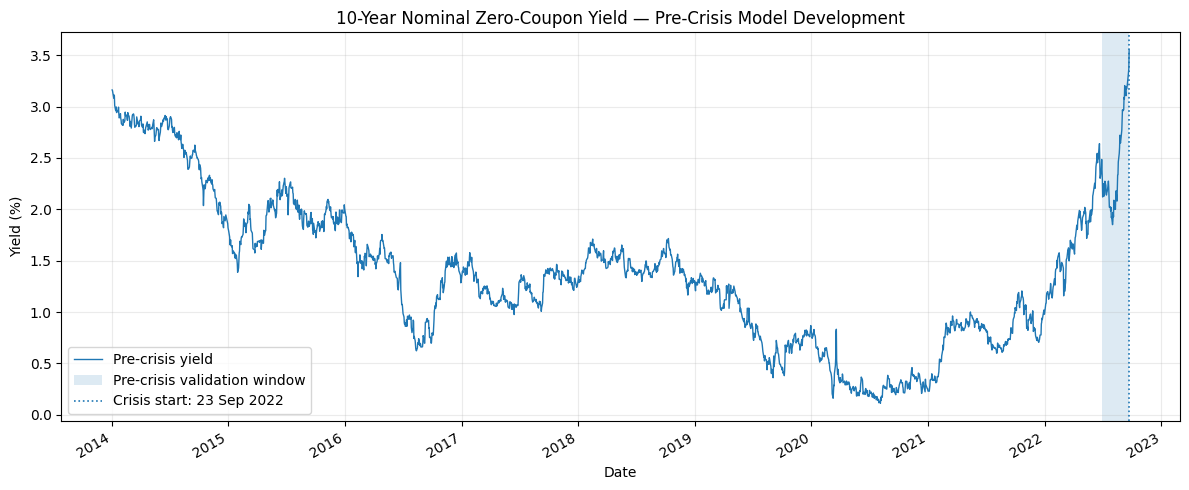

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    pre_crisis["date"],
    pre_crisis["yield_10y"],
    linewidth=1,
    label="Pre-crisis yield"
)

ax.axvspan(
    test_level["date"].min(),
    test_level["date"].max(),
    alpha=0.15,
    label="Pre-crisis validation window"
)

ax.axvline(
    CRISIS_START,
    linestyle=":",
    linewidth=1.2,
    label="Crisis start: 23 Sep 2022"
)

ax.set_title("10-Year Nominal Zero-Coupon Yield — Pre-Crisis Model Development")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Helper functions

The chapter workflow is repeated across model families:

1. generate plausible candidate orders;
2. estimate each candidate on the **training data**;
3. rank candidates by **AIC**;
4. fit the selected model;
5. inspect residuals;
6. forecast the holdout sample;
7. compare forecast accuracy.

AIC is used for **within-family order selection**. AIC values from models fitted to different transformed series should not be compared directly. Final comparison across all six model families is therefore based on holdout forecast errors on the common **yield-level scale**.

In [6]:
def fit_sarimax(
    endog,
    order,
    seasonal_order=(0, 0, 0, 0),
    trend="n"
):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        model = SARIMAX(
            endog,
            order=order,
            seasonal_order=seasonal_order,
            trend=trend,
            simple_differencing=False,
            enforce_stationarity=True,
            enforce_invertibility=True
        )

        fit = model.fit(disp=False)

    return fit


def model_residuals(fit):
    resid = pd.Series(np.asarray(fit.resid), dtype=float)

    burn = int(getattr(fit, "loglikelihood_burn", 0))
    if burn > 0:
        resid = resid.iloc[burn:]

    return resid.dropna().reset_index(drop=True)


def information_table(records):
    table = pd.DataFrame(records)

    if table.empty:
        raise RuntimeError("No candidate model converged.")

    return (
        table
        .sort_values(["AIC", "BIC"])
        .reset_index(drop=True)
    )


def forecast_changes_to_level(fit, last_level, horizon):
    change_forecast_bps = np.asarray(
        fit.get_forecast(steps=horizon).predicted_mean,
        dtype=float
    )

    level_forecast = (
        last_level
        + np.cumsum(change_forecast_bps) / 100
    )

    return level_forecast


def forecast_metrics(actual_level, predicted_level):
    actual = np.asarray(actual_level, dtype=float)
    predicted = np.asarray(predicted_level, dtype=float)

    mae_pct = mean_absolute_error(actual, predicted)
    rmse_pct = np.sqrt(mean_squared_error(actual, predicted))

    return {
        "MAE_percentage_points": mae_pct,
        "RMSE_percentage_points": rmse_pct,
        "MAE_bps": mae_pct * 100,
        "RMSE_bps": rmse_pct * 100,
    }


def plot_level_forecast(predicted_level, model_name, lookback=180):
    plot_start = max(0, len(train_level) - lookback)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        train_level["date"].iloc[plot_start:],
        train_level["yield_10y"].iloc[plot_start:],
        label="Training data"
    )

    ax.plot(
        test_level["date"],
        test_level["yield_10y"],
        label="Actual test data"
    )

    ax.plot(
        test_level["date"],
        predicted_level,
        linestyle="--",
        label=model_name
    )

    ax.axvline(
        test_level["date"].iloc[0],
        linestyle=":",
        linewidth=1
    )

    ax.set_title(f"{model_name} — Forecast versus Actual")
    ax.set_xlabel("Date")
    ax.set_ylabel("10-Year Yield (%)")
    ax.grid(alpha=0.25)
    ax.legend()

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def residual_diagnostics(fit, model_name, lags=(5, 10, 20)):
    resid = model_residuals(fit)

    print(f"{model_name} residual observations: {len(resid)}")
    print(f"Residual mean: {resid.mean():.6f}")
    print(f"Residual standard deviation: {resid.std():.6f}")

    fig = fit.plot_diagnostics(
        figsize=(12, 8),
        lags=max(lags)
    )
    fig.suptitle(
        f"{model_name} — Residual Diagnostics",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

    fig = qqplot(
        resid,
        line="45",
        fit=True
    )
    plt.title(f"{model_name} — Residual Q–Q Plot")
    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(
        resid,
        lags=list(lags),
        return_df=True
    )

    lb.index.name = "lag"

    print("Ljung–Box test:")
    display(lb)

    return lb


def random_walk_diagnostics(innovations, lags=(5, 10, 20)):
    resid = pd.Series(innovations).dropna().astype(float)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(12, 7)
    )

    axes[0].plot(resid.values, linewidth=0.9)
    axes[0].axhline(0, linewidth=0.8)
    axes[0].set_title("Random Walk Errors")
    axes[0].set_xlabel("Training observation")
    axes[0].set_ylabel("Errors (bps)")
    axes[0].grid(alpha=0.25)

    plot_acf(
        resid,
        lags=max(lags),
        zero=False,
        ax=axes[1]
    )
    axes[1].set_title("ACF — Random Walk Errors")
    axes[1].set_xlabel("Lag in market observations")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    fig = qqplot(
        resid,
        line="45",
        fit=True
    )
    plt.title("Random Walk Errors — Q–Q Plot")
    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(
        resid,
        lags=list(lags),
        return_df=True
    )

    lb.index.name = "lag"

    print("Ljung–Box test:")
    display(lb)

    return lb

### Residual-diagnostic interpretation

#### Q–Q plot

The Q–Q plot compares the empirical residual distribution with a Gaussian reference distribution.

- points close to the 45-degree line are consistent with approximate Gaussianity;
- systematic curvature or large tail departures indicate non-normality or heavy tails.

A non-Gaussian Q–Q plot does **not automatically invalidate the conditional-mean model**. In financial data, heavy tails can coexist with a useful mean specification.

#### Ljung–Box test

For each tested lag:

- $H_0$: the residual autocorrelations up to that lag are jointly zero;
- $H_1$: residual serial correlation remains.

A p-value above `0.05` means there is insufficient evidence of remaining linear autocorrelation at that horizon.

The next volatility notebook will separately investigate whether residual **variance** is predictable.

## Part I: Random Walk

### Random Walk benchmark

A Random Walk without drift is

$$
y_t = y_{t-1} + \varepsilon_t.
$$

The best forecast of every future level from a fixed forecast origin is therefore the **last observed yield**.

The Random Walk is especially important here because Notebook 02 found strong persistence and a unit-root-type structure in the yield level. It provides a benchmark that more complicated models must outperform out of sample.

#### Inspect the Random Walk errors

If the yield level follows a Random Walk, its first differences represent the random error term. We therefore inspect the training-sample daily yield changes using the same Q–Q plot, ACF and Ljung–Box diagnostics that will later be applied to fitted-model residuals.

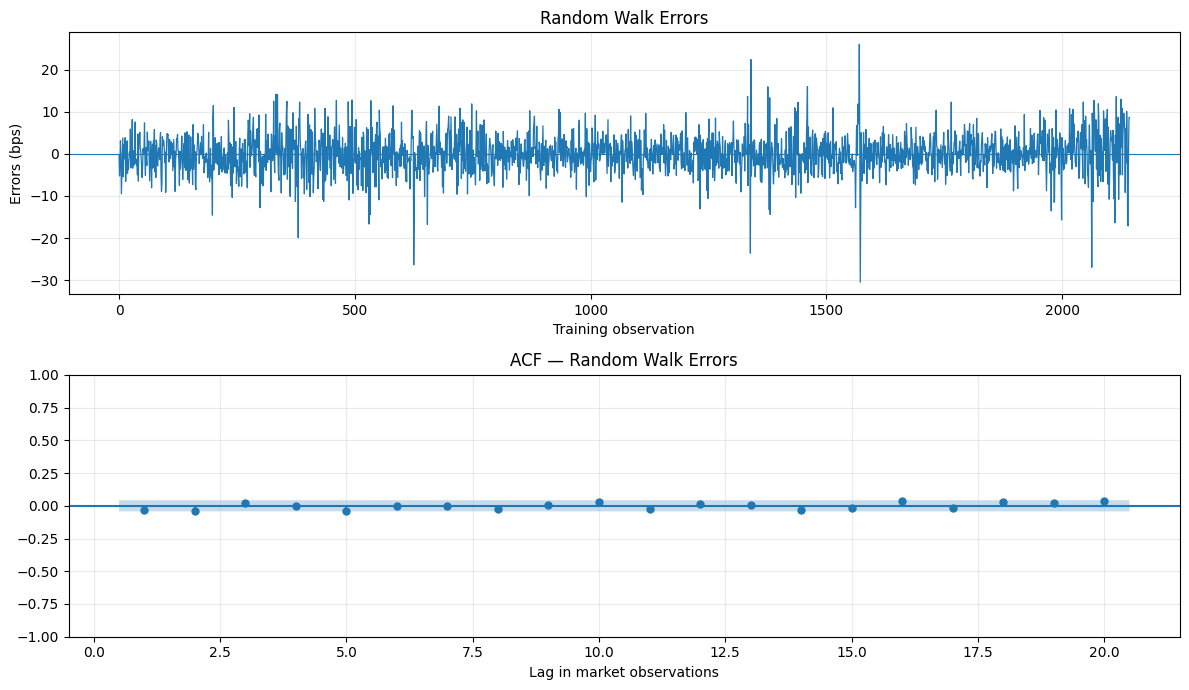

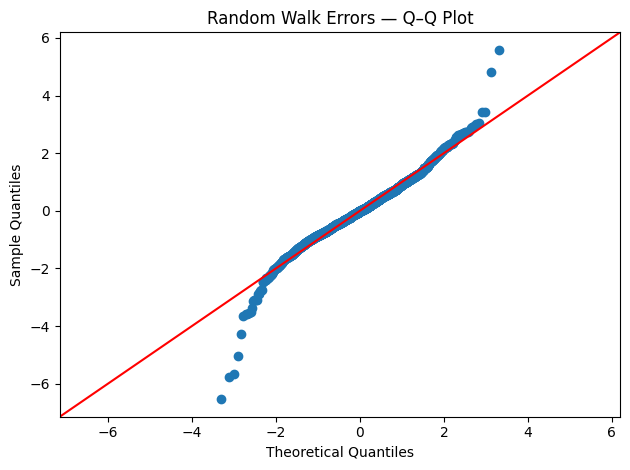

Ljung–Box test:


,lb_stat,lb_pvalue
lag,,
5,10.505394,0.062118
10,13.294109,0.207690
20,25.132021,0.196427


In [7]:
rw_innovations_bps = train_changes.copy()

rw_ljungbox = random_walk_diagnostics(
    rw_innovations_bps,
    lags=(5, 10, 20)
)

#### Random Walk Residual Diagnostics

The Random Walk errors fluctuate around zero and show little evidence of persistent linear dependence. The ACF values are generally small and remain close to the confidence band.

The Ljung–Box test gives p-values of **0.062**, **0.208**, and **0.196** at lags 5, 10, and 20 respectively. Since all are above the 5% significance level, there is insufficient evidence to reject the null hypothesis of no residual autocorrelation. The lag-5 result is relatively close to 0.05, but it is still not statistically significant at the chosen threshold.

The Q–Q plot shows substantial departures from the normal reference line in both tails, indicating that the errors are **heavy-tailed rather than normally distributed**. The residual time-series plot also shows periods where the magnitude of errors becomes noticeably larger, suggesting that the variance is not constant through time.

The Random Walk captures the conditional mean reasonably well in the sense that little linear autocorrelation remains, but the heavy tails and changing dispersion indicate that it does not capture the full behaviour of the error variance.

#### Forecast the holdout sample

In [8]:
rw_forecast = np.repeat(
    LAST_TRAIN_LEVEL,
    HORIZON
)

rw_metrics = forecast_metrics(
    test_level["yield_10y"],
    rw_forecast
)

pd.Series(rw_metrics, name="Random Walk")

MAE_percentage_points      0.421998
RMSE_percentage_points     0.473040
MAE_bps                   42.199833
RMSE_bps                  47.303980
Name: Random Walk, dtype: float64

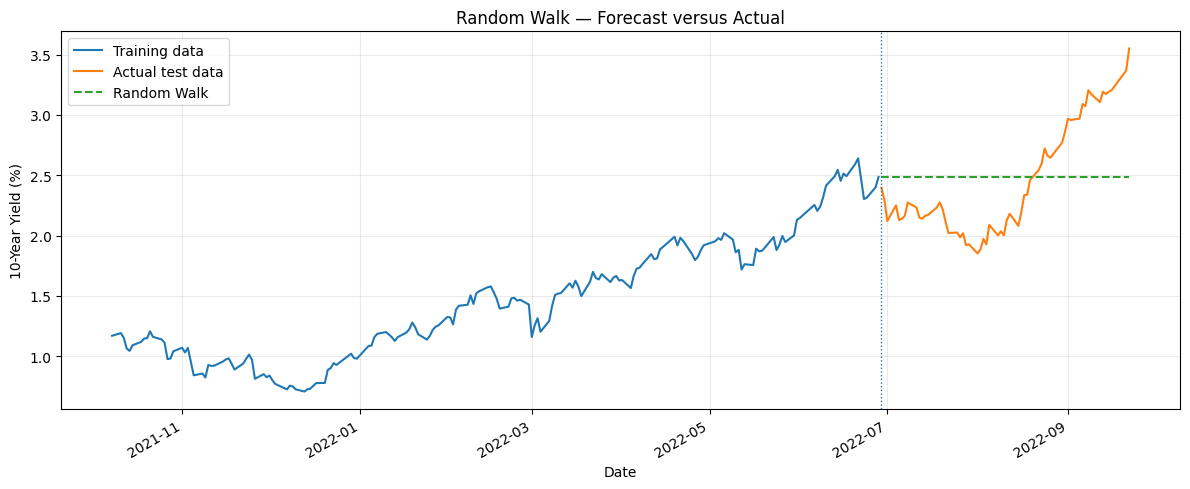

In [9]:
plot_level_forecast(
    rw_forecast,
    "Random Walk"
)

#### Random Walk: Pre-Crisis Forecast Performance

The Random Walk produces a constant fixed-origin forecast at approximately the final training yield of **2.49%**. During the pre-crisis validation period, however, the observed 10-year yield initially falls below this level before rising sharply towards the end of the period. The model therefore fails to capture the substantial movement in yields during the holdout sample.

The out-of-sample **MAE is 0.422 percentage points (42.20 bps)** and the **RMSE is 0.473 percentage points (47.30 bps)**. The larger RMSE reflects the relatively large forecast errors that occur as the observed yield moves progressively further away from the constant Random Walk forecast.

This result provides a useful benchmark for the other conditional-mean models. It also shows the limitation of a fixed-origin Random Walk forecast when the yield level changes substantially over the forecast horizon.

## Part II: Autoregressive Model

### AR((p)) model

For the stationary daily-change representation,

$$
x_t = c + \phi_1x_{t-1}+\cdots+\phi_px_{t-p}+\varepsilon_t,
$$

where $x_t$ is the daily change in the 10-year yield in basis points.

- An AR process generally has an ACF that decays rather than cutting off sharply;
- the **PACF** is particularly useful for identifying plausible AR orders;
- AIC is then used to compare candidate orders quantitatively.

Only the training sample is used for order selection.

#### PACF of training-sample daily changes

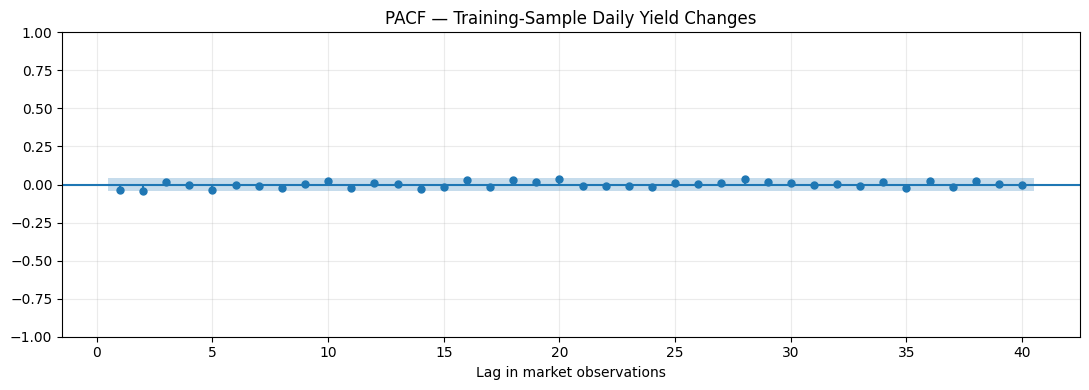

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))

plot_pacf(
    train_changes,
    lags=40,
    zero=False,
    method="ywm",
    ax=ax
)

ax.set_title("PACF — Training-Sample Daily Yield Changes")
ax.set_xlabel("Lag in market observations")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Select the AR order using AIC

In [11]:
AR_MAX_P = 10

ar_records = []

for p in range(1, AR_MAX_P + 1):
    try:
        fit = fit_sarimax(
            train_changes,
            order=(p, 0, 0),
            trend="c"
        )

        ar_records.append({
            "p": p,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True)
        })

    except Exception as exc:
        ar_records.append({
            "p": p,
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False
        })

ar_selection = (
    pd.DataFrame(ar_records)
    .dropna(subset=["AIC"])
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

ar_selection

,p,AIC,BIC,converged
0,2,12688.732657,12711.414371,True
1,3,12690.223804,12718.575946,True
2,1,12690.836156,12707.847441,True
3,5,12690.941386,12730.634386,True
4,4,12692.217240,12726.239811,True
5,6,12692.869826,12738.233254,True
6,7,12694.774325,12745.808182,True
7,8,12695.588119,12752.292404,True
8,9,12697.579919,12759.954632,True
9,10,12698.410529,12766.455671,True


In [12]:
best_ar_p = int(ar_selection.loc[0, "p"])

print(f"Selected AR order by AIC: p = {best_ar_p}")

ar_fit = fit_sarimax(
    train_changes,
    order=(best_ar_p, 0, 0),
    trend="c"
)

print(ar_fit.summary())

Selected AR order by AIC: p = 2
                               SARIMAX Results                                
Dep. Variable:       yield_change_bps   No. Observations:                 2144
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -6340.366
Date:                Sat, 29 Aug 2026   AIC                          12688.733
Time:                        17:22:26   BIC                          12711.414
Sample:                             0   HQIC                         12697.032
                               - 2144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0343      0.102     -0.337      0.736      -0.234       0.165
ar.L1         -0.0351      0.016     -2.197      0.028      -0.066      -0.004
ar.L2         -0.043

#### AR residual analysis

The four-panel diagnostics include standardised residuals, their distribution, a Q–Q plot and the residual correlogram. A separate Q–Q plot is also displayed for readability, followed by the Ljung–Box test.

AR(2) residual observations: 2144
Residual mean: -0.000225
Residual standard deviation: 4.657853


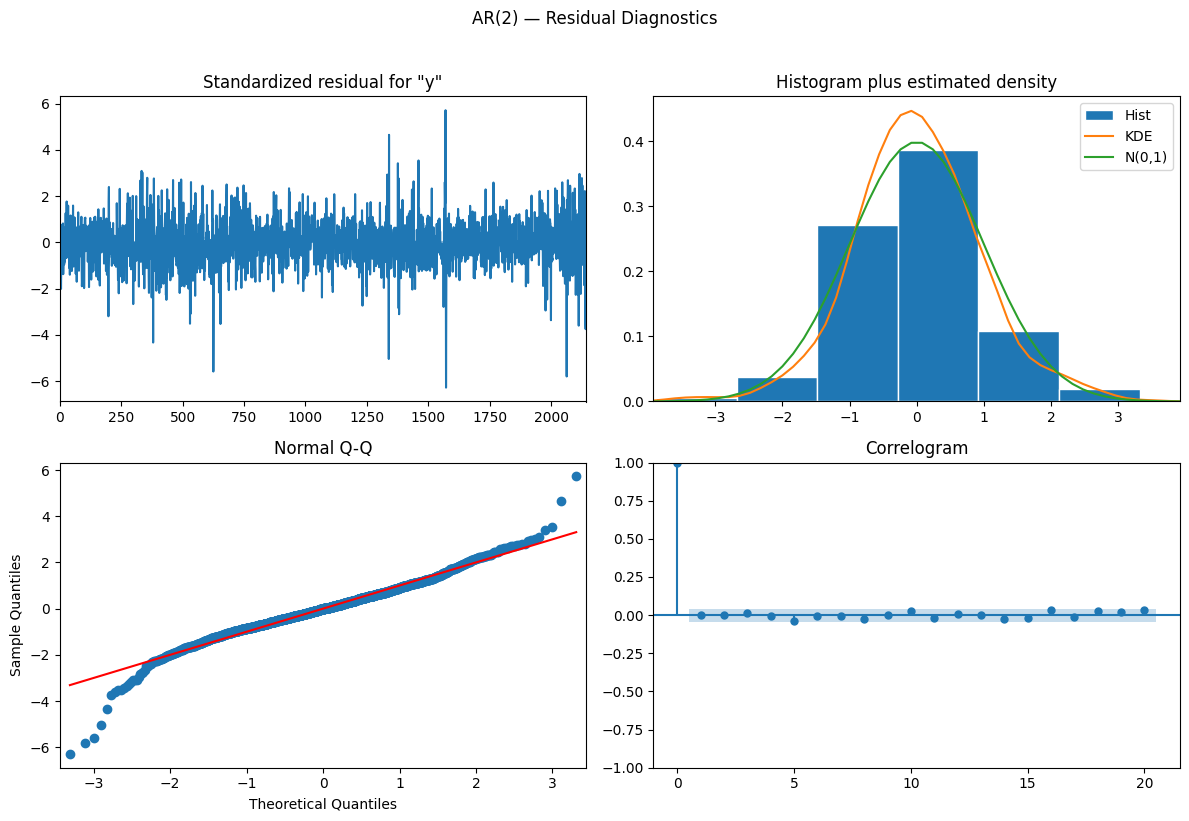

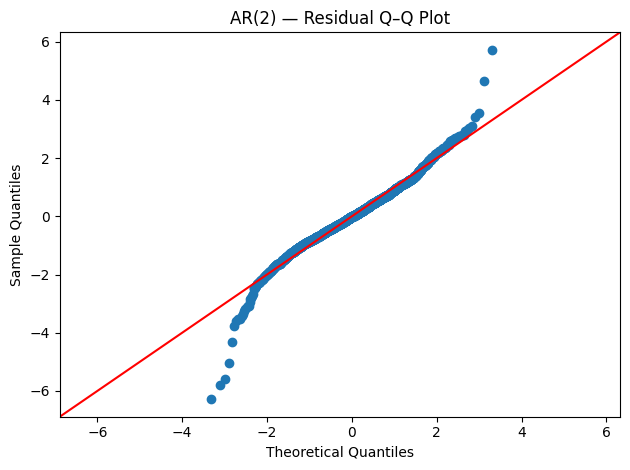

Ljung–Box test:


,lb_stat,lb_pvalue
lag,,
5,3.811641,0.576841
10,6.477609,0.773669
20,18.235429,0.571903


In [13]:
ar_ljungbox = residual_diagnostics(
    ar_fit,
    f"AR({best_ar_p})"
)

#### Forecast daily changes and reconstruct the yield level

Because the AR model is fitted to first differences, its predicted changes must be cumulatively summed and added to the final training yield to return to the original yield scale.

In [14]:
ar_forecast = forecast_changes_to_level(
    ar_fit,
    LAST_TRAIN_LEVEL,
    HORIZON
)

ar_metrics = forecast_metrics(
    test_level["yield_10y"],
    ar_forecast
)

pd.Series(
    ar_metrics,
    name=f"AR({best_ar_p})"
)

MAE_percentage_points      0.421265
RMSE_percentage_points     0.476546
MAE_bps                   42.126463
RMSE_bps                  47.654583
Name: AR(2), dtype: float64

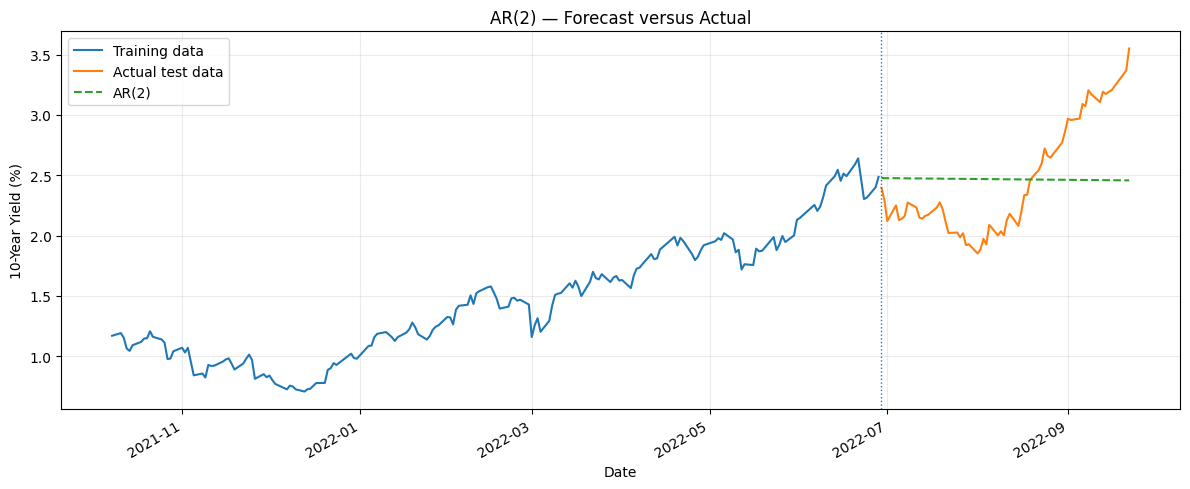

In [15]:
plot_level_forecast(
    ar_forecast,
    f"AR({best_ar_p})"
)

#### AR(2): Pre-Crisis Forecast Performance

The AR(2) fixed-origin forecast remains close to the final training yield, at approximately **2.5%**, with only a small initial adjustment. It therefore behaves very similarly to the Random Walk forecast. The observed yield, however, initially falls below the forecast before subsequently rising sharply towards the end of the pre-crisis validation period.

The out-of-sample **MAE is 0.421 percentage points (42.13 bps)** and the **RMSE is 0.477 percentage points (47.65 bps)**. This represents almost no improvement over the Random Walk benchmark: AR(2) has a slightly lower MAE but a slightly higher RMSE.

Although AR(2) adequately removes linear autocorrelation from the training-sample changes, this does not translate into a meaningful improvement in longer-horizon fixed-origin forecasting. The result suggests that the limited autoregressive dependence in daily yield changes provides little additional information for predicting the future yield path over this validation period.

## Part III: Moving Average Model

### MA(q) model

For the stationary daily-change representation,

$$
x_t = c + \varepsilon_t
      + \theta_1\varepsilon_{t-1}
      + \cdots
      + \theta_q\varepsilon_{t-q}.
$$

- the ACF of a true MA(\(q\)) process theoretically cuts off after lag \(q\);
- the **ACF** is therefore inspected for plausible MA orders;
- candidate values of \(q\) are then ranked by AIC.

The errors themselves should behave like white noise after a suitable model has been fitted.

#### ACF of training-sample daily changes

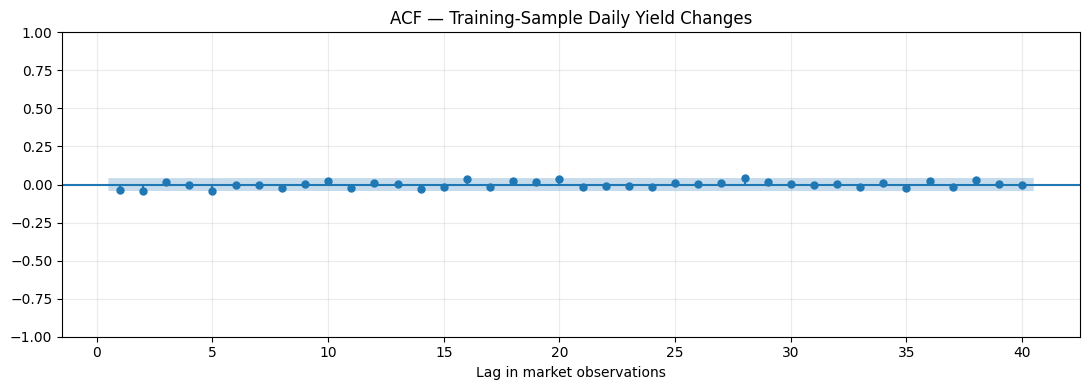

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))

plot_acf(
    train_changes,
    lags=40,
    zero=False,
    ax=ax
)

ax.set_title("ACF — Training-Sample Daily Yield Changes")
ax.set_xlabel("Lag in market observations")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Select the MA order using AIC

In [17]:
MA_MAX_Q = 10

ma_records = []

for q in range(1, MA_MAX_Q + 1):
    try:
        fit = fit_sarimax(
            train_changes,
            order=(0, 0, q),
            trend="c"
        )

        ma_records.append({
            "q": q,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True)
        })

    except Exception:
        ma_records.append({
            "q": q,
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False
        })

ma_selection = (
    pd.DataFrame(ma_records)
    .dropna(subset=["AIC"])
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

ma_selection

,q,AIC,BIC,converged
0,2,12688.900445,12711.582159,True
1,3,12690.427471,12718.779614,True
2,1,12690.611981,12707.623266,True
3,5,12691.046317,12730.739317,True
4,4,12692.391201,12726.413772,True
5,6,12692.965897,12738.329325,True
6,7,12694.919323,12745.953179,True
7,8,12696.010357,12752.714643,True
8,9,12698.004592,12760.379306,True
9,10,12698.605105,12766.650247,True


In [18]:
best_ma_q = int(ma_selection.loc[0, "q"])

print(f"Selected MA order by AIC: q = {best_ma_q}")

ma_fit = fit_sarimax(
    train_changes,
    order=(0, 0, best_ma_q),
    trend="c"
)

print(ma_fit.summary())

Selected MA order by AIC: q = 2
                               SARIMAX Results                                
Dep. Variable:       yield_change_bps   No. Observations:                 2144
Model:               SARIMAX(0, 0, 2)   Log Likelihood               -6340.450
Date:                Sat, 29 Aug 2026   AIC                          12688.900
Time:                        17:22:31   BIC                          12711.582
Sample:                             0   HQIC                         12697.199
                               - 2144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0319      0.094     -0.338      0.735      -0.216       0.153
ma.L1         -0.0339      0.016     -2.099      0.036      -0.065      -0.002
ma.L2         -0.042

#### MA residual analysis

MA(2) residual observations: 2144
Residual mean: -0.000165
Residual standard deviation: 4.658035


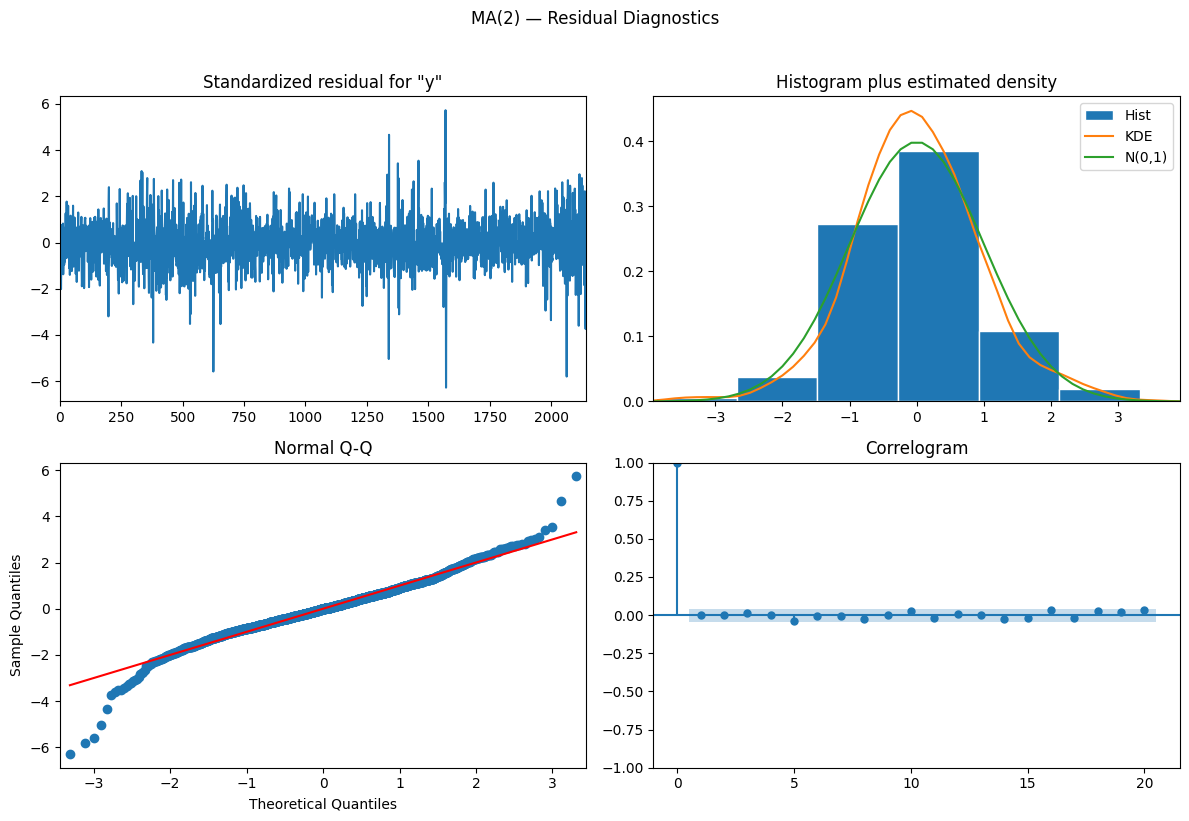

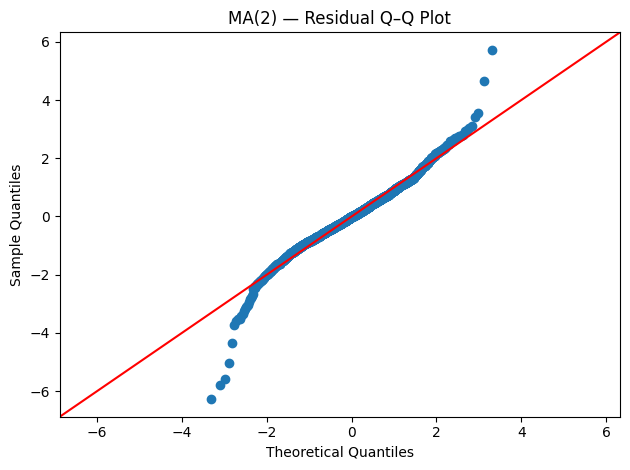

Ljung–Box test:


,lb_stat,lb_pvalue
lag,,
5,3.992312,0.550523
10,6.661928,0.756929
20,18.428268,0.559219


In [19]:
ma_ljungbox = residual_diagnostics(
    ma_fit,
    f"MA({best_ma_q})"
)

#### MA Model Selection and Residual Diagnostics

The ACF of the pre-crisis training-sample daily yield changes shows only weak autocorrelation, with most coefficients close to zero. This indicates that short-run linear dependence in yield changes is limited.

Among the MA specifications considered, **AIC selects MA(2)** with an AIC of **12688.90**. Both MA coefficients are statistically significant at the 5% level (`MA(1): p = 0.036`, `MA(2): p = 0.010`), while the intercept is not statistically significant (`p = 0.735`). However, **BIC favours the simpler MA(1)** specification, again indicating that the improvement from including the second lag is relatively small once model complexity is penalised more strongly.

The MA(2) residuals have a mean close to zero (**−0.0002 bps**) and a standard deviation of approximately **4.66 bps**. The Ljung–Box p-values at lags 5, 10 and 20 are **0.551, 0.757 and 0.559**, respectively. Since all are well above 0.05, there is no statistically significant evidence of remaining residual autocorrelation. The residual correlogram supports this conclusion.

The Q–Q plot shows clear departures from the normal reference line in both tails. This is consistent with the **Jarque–Bera test (`p < 0.001`)** and kurtosis of **6.12**, indicating a heavy-tailed residual distribution. In contrast, the heteroskedasticity test gives `p = 0.82`, so this particular diagnostic does not provide evidence of a systematic change in residual variance across the sample.

#### Forecast daily changes and reconstruct the yield level

In [20]:
ma_forecast = forecast_changes_to_level(
    ma_fit,
    LAST_TRAIN_LEVEL,
    HORIZON
)

ma_metrics = forecast_metrics(
    test_level["yield_10y"],
    ma_forecast
)

pd.Series(
    ma_metrics,
    name=f"MA({best_ma_q})"
)

MAE_percentage_points      0.421225
RMSE_percentage_points     0.476554
MAE_bps                   42.122530
RMSE_bps                  47.655450
Name: MA(2), dtype: float64

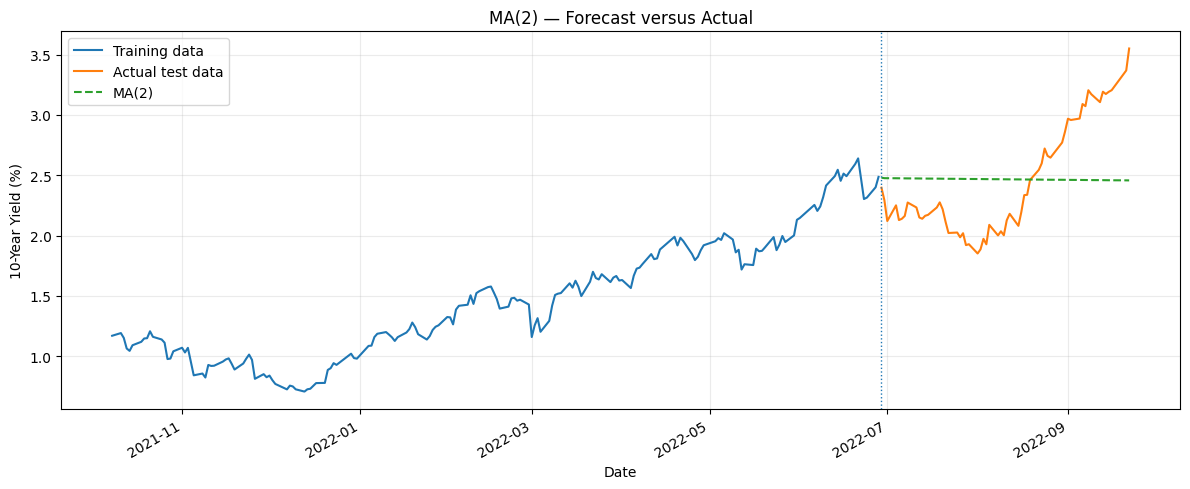

In [21]:
plot_level_forecast(
    ma_forecast,
    f"MA({best_ma_q})"
)

#### MA(2): Pre-Crisis Forecast Performance

The MA(2) fixed-origin forecast remains close to the final training yield, at approximately **2.5%**, with only a very small short-run adjustment. Its forecast path is therefore almost identical to those produced by the Random Walk and AR(2) models.

During the pre-crisis validation period, the observed 10-year yield initially falls below the forecast before rising strongly towards September 2022. The MA(2) model does not anticipate this sustained movement.

The out-of-sample **MAE is 0.421 percentage points (42.12 bps)** and the **RMSE is 0.477 percentage points (47.66 bps)**. These values are extremely close to the AR(2) and Random Walk results, indicating that the moving-average dependence identified in daily yield changes provides very little improvement in longer-horizon fixed-origin forecasting.

The MA(2) performs similarly to the simpler benchmark models. Its limited improvement supports the earlier finding that pre-crisis daily yield changes contain relatively little predictable linear structure in the conditional mean.

## Part IV: ARMA Model

### ARMA(\(p,q\)) model

An ARMA model combines autoregressive and moving-average structure:

$$
x_t =
c
+
\phi_1x_{t-1}
+\cdots+
\phi_px_{t-p}
+
\varepsilon_t
+
\theta_1\varepsilon_{t-1}
+\cdots+
\theta_q\varepsilon_{t-q}.
$$

The procedure is:

1. work with the stationary daily-change series;
2. inspect ACF/PACF for general dependence;
3. search plausible \((p,q)\) combinations;
4. rank them using AIC;
5. perform residual diagnostics on the selected specification.

Because pure AR and pure MA models were already evaluated separately, this section searches combinations with both \(p>0\) and \(q>0\).

#### ACF and PACF of the modelling series

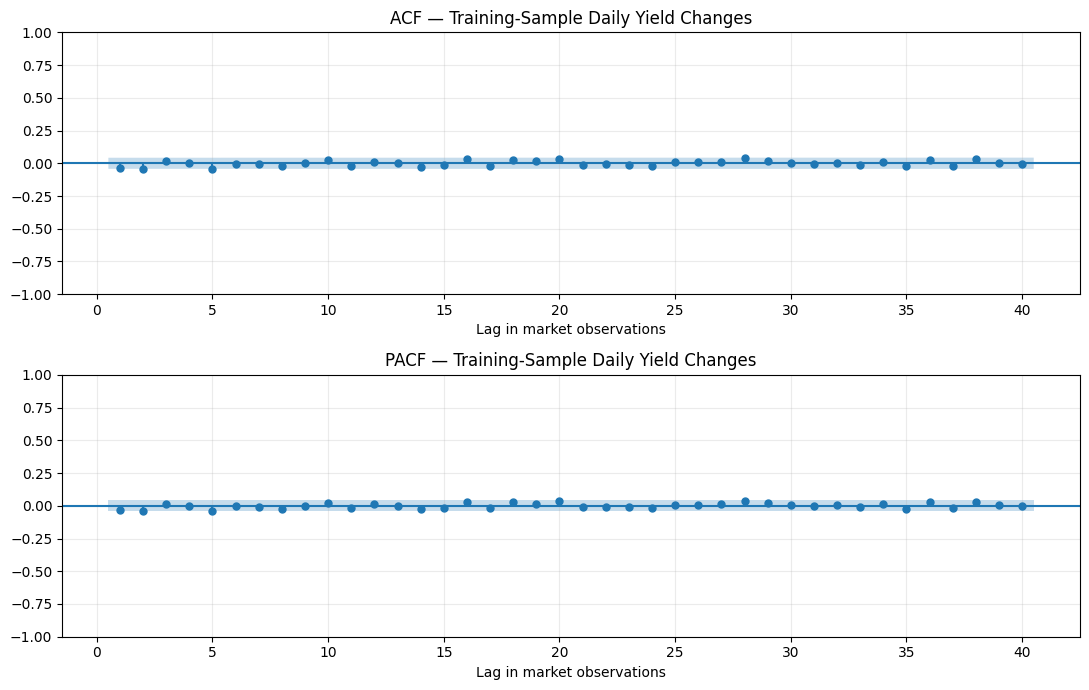

In [22]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 7)
)

plot_acf(
    train_changes,
    lags=40,
    zero=False,
    ax=axes[0]
)
axes[0].set_title("ACF — Training-Sample Daily Yield Changes")
axes[0].set_xlabel("Lag in market observations")
axes[0].grid(alpha=0.25)

plot_pacf(
    train_changes,
    lags=40,
    zero=False,
    method="ywm",
    ax=axes[1]
)
axes[1].set_title("PACF — Training-Sample Daily Yield Changes")
axes[1].set_xlabel("Lag in market observations")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Select ARMA orders using AIC

In [23]:
import warnings
warnings.filterwarnings("ignore")

ARMA_MAX_P = 4
ARMA_MAX_Q = 4

arma_orders = list(
    product(
        range(1, ARMA_MAX_P + 1),
        range(1, ARMA_MAX_Q + 1)
    )
)

arma_records = []

for p, q in arma_orders:
    try:
        fit = fit_sarimax(
            train_changes,
            order=(p, 0, q),
            trend="c"
        )

        arma_records.append({
            "p": p,
            "q": q,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True)
        })

    except Exception:
        arma_records.append({
            "p": p,
            "q": q,
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False
        })

arma_selection = (
    pd.DataFrame(arma_records)
    .dropna(subset=["AIC"])
    .query("converged == True")
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

arma_selection.head(10)

,p,q,AIC,BIC,converged
0,2,2,12687.629235,12721.651806,True
1,3,2,12688.068757,12727.761757,True
2,3,3,12688.321972,12733.685400,True
3,1,1,12689.910444,12712.592158,True
4,2,1,12690.363628,12718.715771,True
5,1,2,12690.546829,12718.898972,True
6,3,1,12692.222796,12726.245367,True
7,1,3,12692.422069,12726.444640,True
8,4,1,12692.564925,12732.257925,True
9,1,4,12692.738744,12732.431744,True


In [24]:
best_arma_p = int(arma_selection.loc[0, "p"])
best_arma_q = int(arma_selection.loc[0, "q"])

print(
    f"Selected ARMA order by AIC: "
    f"({best_arma_p}, {best_arma_q})"
)

arma_fit = fit_sarimax(
    train_changes,
    order=(best_arma_p, 0, best_arma_q),
    trend="c"
)

print(arma_fit.summary())

Selected ARMA order by AIC: (2, 2)
                               SARIMAX Results                                
Dep. Variable:       yield_change_bps   No. Observations:                 2144
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -6337.815
Date:                Sat, 29 Aug 2026   AIC                          12687.629
Time:                        17:22:43   BIC                          12721.652
Sample:                             0   HQIC                         12700.078
                               - 2144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0836      0.266     -0.314      0.753      -0.605       0.438
ar.L1         -0.7575      0.059    -12.897      0.000      -0.873      -0.642
ar.L2         -0.

#### ARMA residual analysis

ARMA(2,2) residual observations: 2144
Residual mean: -0.000008
Residual standard deviation: 4.652302


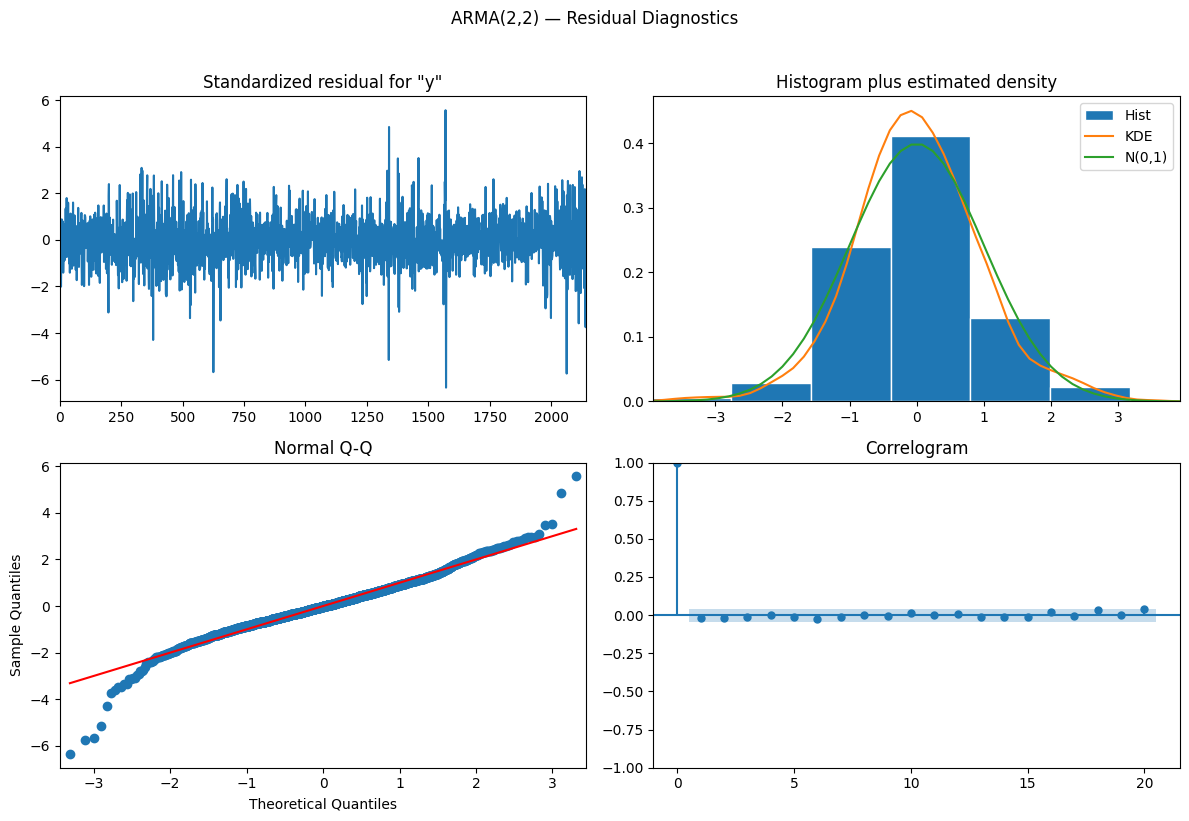

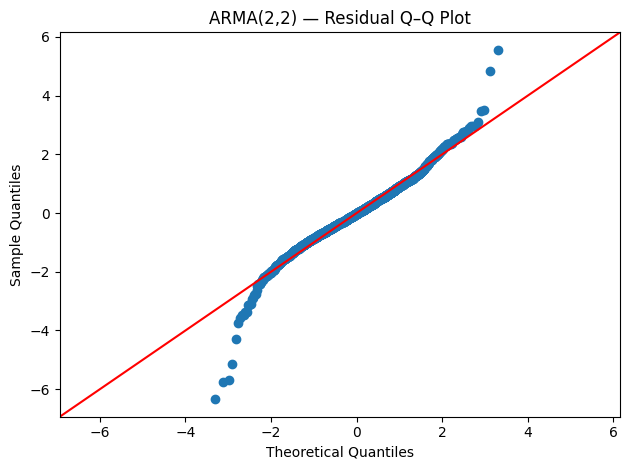

Ljung–Box test:


,lb_stat,lb_pvalue
lag,,
5,2.294711,0.807043
10,4.352654,0.930039
20,12.691815,0.890212


In [25]:
arma_ljungbox = residual_diagnostics(
    arma_fit,
    f"ARMA({best_arma_p},{best_arma_q})"
)

#### ARMA Model Selection and Residual Diagnostics

The ACF and PACF of the pre-crisis training-sample daily yield changes show only weak linear dependence, with most coefficients close to zero. This suggests that any ARMA structure in the conditional mean is relatively limited.

Among the ARMA specifications considered, **AIC selects ARMA(2,2)** with an AIC of **12687.63**. All four AR and MA coefficients are statistically significant (`p < 0.001`), while the intercept is not statistically significant (`p = 0.753`). However, **BIC favours the simpler ARMA(1,1)** specification within the ARMA candidates, indicating that the additional parameters in ARMA(2,2) provide only a modest improvement once model complexity is penalised more strongly.

The ARMA(2,2) residuals have a mean extremely close to zero (**−0.000008 bps**) and a standard deviation of approximately **4.65 bps**. The Ljung–Box p-values at lags 5, 10 and 20 are **0.807, 0.930 and 0.890**, respectively. These are all well above 0.05, providing no statistically significant evidence of remaining residual autocorrelation. The residual correlogram is consistent with this result.

The Q–Q plot nevertheless shows pronounced departures from the normal reference line in both tails. This is supported by the **Jarque–Bera test (`p < 0.001`)** and kurtosis of **6.13**, indicating a heavy-tailed residual distribution. The heteroskedasticity diagnostic gives `p = 0.91`, so this particular test does not indicate a systematic change in residual variance across the pre-crisis training sample.

#### Forecast daily changes and reconstruct the yield level

In [26]:
arma_forecast = forecast_changes_to_level(
    arma_fit,
    LAST_TRAIN_LEVEL,
    HORIZON
)

arma_metrics = forecast_metrics(
    test_level["yield_10y"],
    arma_forecast
)

pd.Series(
    arma_metrics,
    name=f"ARMA({best_arma_p},{best_arma_q})"
)

MAE_percentage_points      0.424404
RMSE_percentage_points     0.476980
MAE_bps                   42.440417
RMSE_bps                  47.698000
Name: ARMA(2,2), dtype: float64

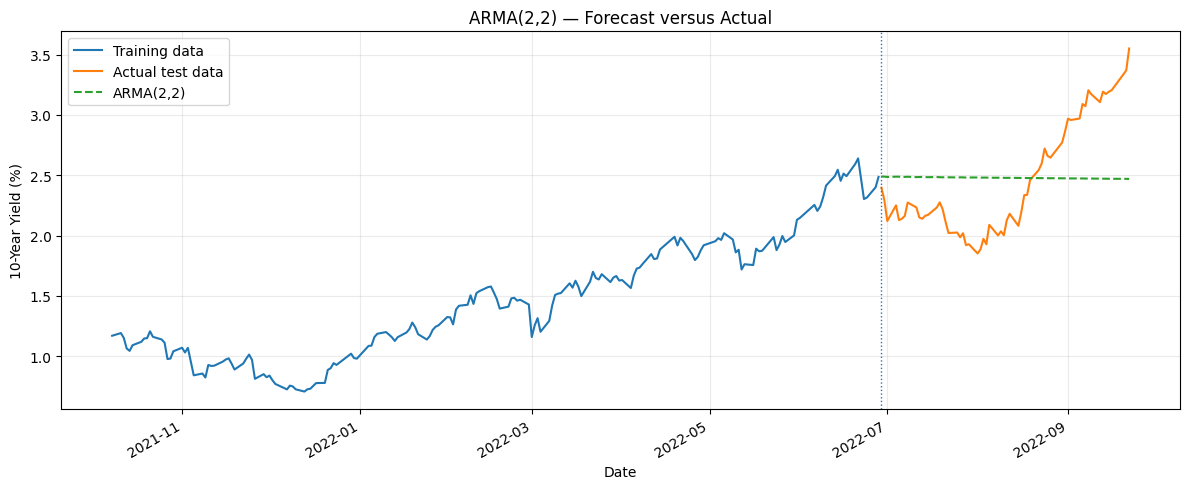

In [27]:
plot_level_forecast(
    arma_forecast,
    f"ARMA({best_arma_p},{best_arma_q})"
)

#### ARMA(2,2): Pre-Crisis Forecast Performance

The ARMA(2,2) fixed-origin forecast remains close to the final training yield of approximately **2.5%**, with only very small movements over the forecast horizon. The observed yield, however, initially falls below the forecast before rising strongly as September 2022 approaches.

The out-of-sample **MAE is 0.424 percentage points (42.44 bps)** and the **RMSE is 0.477 percentage points (47.70 bps)**. These errors are extremely similar to those of the Random Walk, AR(2), and MA(2) models.

Although ARMA(2,2) achieved the lowest AIC among the ARMA candidates and removed residual linear autocorrelation effectively, this additional model complexity does not translate into better fixed-origin forecast accuracy. Its MAE and RMSE are slightly worse than those of the simpler AR(2) and MA(2) models.

The ARMA(2,2) result reinforces the conclusion that the pre-crisis daily yield changes contain only limited exploitable linear dependence. More complex conditional-mean dynamics provide little improvement in forecasting the longer-horizon yield path.

## Part V: ARIMA Model

### ARIMA(\(p,d,q\)) model

ARIMA extends ARMA to a non-stationary level series by incorporating differencing:

$$
\phi(B)(1-B)^d y_t = \theta(B)\varepsilon_t.
$$

Notebook 02 found strong evidence that the yield **level** is non-stationary, while first differencing removes the dominant unit-root behaviour. Therefore this notebook fixes:$d=1.$

The remaining \(p\) and \(q\) orders are selected using AIC on the training sample.

#### Select ARIMA orders using AIC

In [28]:
ARIMA_MAX_P = 4
ARIMA_MAX_Q = 4
ARIMA_D = 1

arima_orders = list(
    product(
        range(0, ARIMA_MAX_P + 1),
        range(0, ARIMA_MAX_Q + 1)
    )
)

arima_records = []

for p, q in arima_orders:
    try:
        fit = fit_sarimax(
            train_level["yield_10y"],
            order=(p, ARIMA_D, q),
            trend="n"
        )

        arima_records.append({
            "p": p,
            "d": ARIMA_D,
            "q": q,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True)
        })

    except Exception:
        arima_records.append({
            "p": p,
            "d": ARIMA_D,
            "q": q,
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False
        })

arima_selection = (
    pd.DataFrame(arima_records)
    .dropna(subset=["AIC"])
    .query("converged == True")
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

arima_selection.head(10)

,p,d,q,AIC,BIC,converged
0,2,1,2,-7061.238945,-7032.886802,True
1,2,1,0,-7060.120134,-7043.108848,True
2,0,1,2,-7059.947151,-7042.935866,True
3,3,1,0,-7058.632874,-7035.951160,True
4,0,1,3,-7058.418715,-7035.737001,True
5,2,1,1,-7058.293375,-7035.611661,True
6,0,1,1,-7058.243573,-7046.902716,True
7,1,1,2,-7058.203206,-7035.521492,True
8,1,1,0,-7058.027967,-7046.687110,True
9,0,1,0,-7057.623614,-7051.953186,True


In [29]:
best_arima_p = int(arima_selection.loc[0, "p"])
best_arima_d = int(arima_selection.loc[0, "d"])
best_arima_q = int(arima_selection.loc[0, "q"])

best_arima_order = (
    best_arima_p,
    best_arima_d,
    best_arima_q
)

print(
    "Selected ARIMA order by AIC:",
    best_arima_order
)

arima_fit = fit_sarimax(
    train_level["yield_10y"],
    order=best_arima_order,
    trend="n"
)

print(arima_fit.summary())

Selected ARIMA order by AIC: (2, 1, 2)
                               SARIMAX Results                                
Dep. Variable:              yield_10y   No. Observations:                 2145
Model:               SARIMAX(2, 1, 2)   Log Likelihood                3535.619
Date:                Sat, 29 Aug 2026   AIC                          -7061.239
Time:                        17:22:49   BIC                          -7032.887
Sample:                             0   HQIC                         -7050.865
                               - 2145                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7578      0.059    -12.941      0.000      -0.873      -0.643
ar.L2         -0.9021      0.057    -15.771      0.000      -1.014      -0.790
ma.L1        

#### ARIMA residual analysis

ARIMA(2, 1, 2) residual observations: 2144
Residual mean: -0.000320
Residual standard deviation: 0.046523


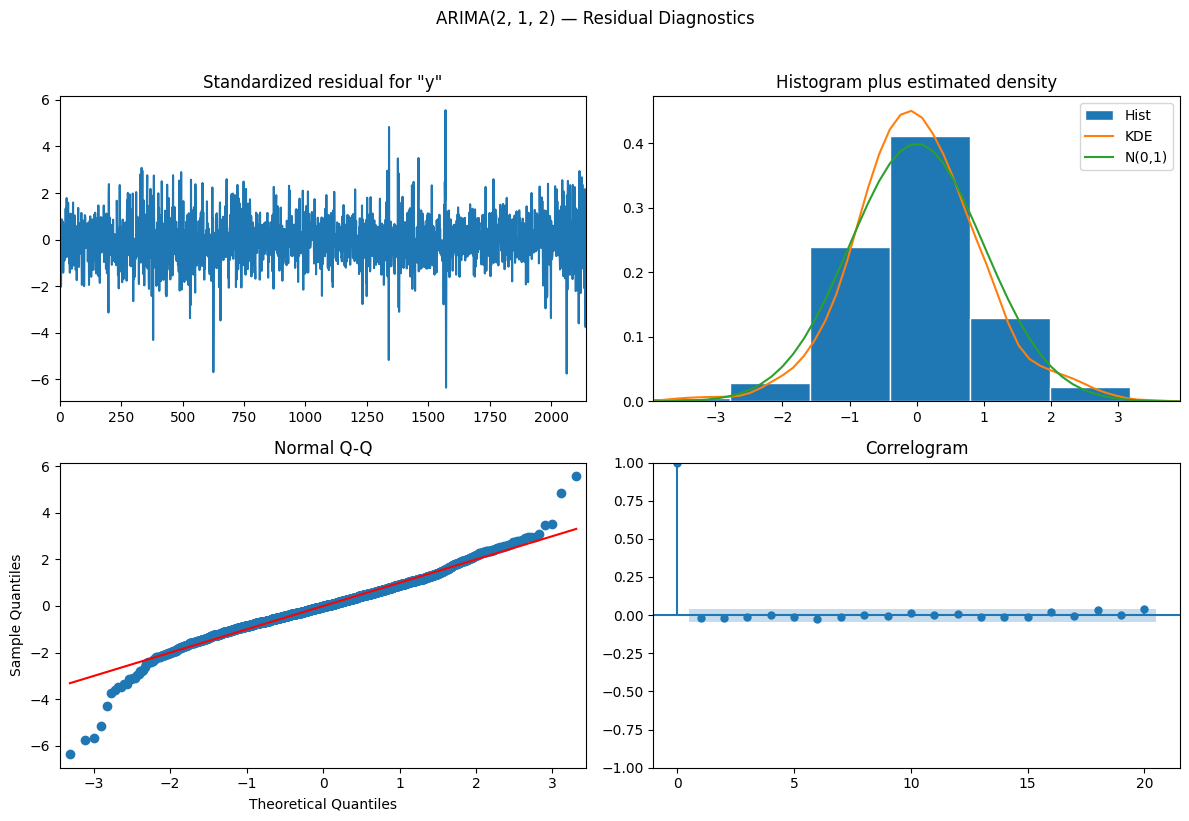

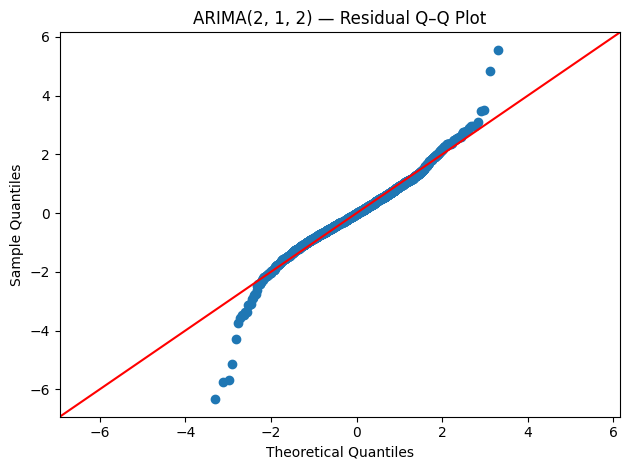

Ljung–Box test:


,lb_stat,lb_pvalue
lag,,
5,2.295267,0.806962
10,4.354547,0.929939
20,12.693827,0.890131


In [30]:
arima_ljungbox = residual_diagnostics(
    arima_fit,
    f"ARIMA{best_arima_order}"
)

#### ARIMA Model Selection and Residual Diagnostics

After excluding non-converged specifications, **AIC selects ARIMA(2,1,2)** with an AIC of **−7061.24** and BIC of **−7032.89**. The first-order differencing accounts for the non-stationarity of the yield level, while the AR(2) and MA(2) components model short-run dependence in daily yield changes. However, **BIC favours the much simpler ARIMA(0,1,0)**, indicating that the improvement in fit from the additional AR and MA parameters is relatively small once model complexity is penalised more heavily.

The estimated AR and MA coefficients are statistically significant, while the residual mean is effectively zero at **−0.00032 percentage points**. The residual standard deviation is approximately **0.0465 percentage points**, or **4.65 bps**.

The residual correlogram shows very little remaining linear dependence. The Ljung–Box tests at lags 5, 10 and 20 give p-values of **0.807, 0.930 and 0.890**, respectively. Since these are all well above 0.05, there is no evidence of statistically significant residual autocorrelation at these lags.

The residual distribution is clearly non-normal. The Q–Q plot shows substantial departures from the reference line in both tails, while the **Jarque–Bera test gives `p < 0.001`** and kurtosis is **6.13**. This indicates a substantially heavier-tailed residual distribution than the normal distribution.

The reported heteroskedasticity test gives **H = 0.99 with `p = 0.90`**, so this particular diagnostic does not provide evidence against constant residual variance. This test should not, however, be treated as a direct test for ARCH effects; separate diagnostics based on squared residuals and an ARCH-LM test are required before drawing conclusions about conditional volatility.

#### Forecast the yield level

In [31]:
arima_forecast = np.asarray(
    arima_fit
    .get_forecast(steps=HORIZON)
    .predicted_mean,
    dtype=float
)

arima_metrics = forecast_metrics(
    test_level["yield_10y"],
    arima_forecast
)

pd.Series(
    arima_metrics,
    name=f"ARIMA{best_arima_order}"
)

MAE_percentage_points      0.422580
RMSE_percentage_points     0.473187
MAE_bps                   42.258042
RMSE_bps                  47.318736
Name: ARIMA(2, 1, 2), dtype: float64

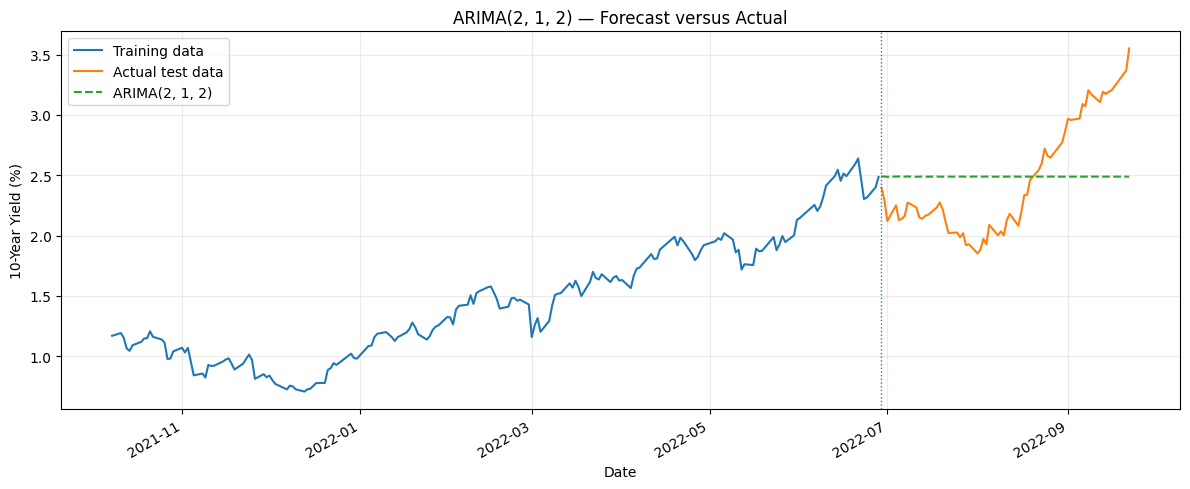

In [32]:
plot_level_forecast(
    arima_forecast,
    f"ARIMA{best_arima_order}"
)

#### ARIMA(2,1,2) Forecast Performance

The ARIMA(2,1,2) model produces an out-of-sample **MAE of 0.423 percentage points (42.26 bps)** and an **RMSE of 0.473 percentage points (47.32 bps)**.

The RMSE is higher than the MAE, indicating that some forecast errors are considerably larger than the typical absolute error. This suggests that the model struggles particularly when yields move substantially away from the forecast path.

Although ARIMA(2,1,2) was selected by AIC within the ARIMA candidate set, these results show that good in-sample fit does not necessarily translate into highly accurate out-of-sample forecasts. The forecast errors remain economically substantial, so the model's performance should ultimately be assessed relative to the other conditional-mean models and the random-walk benchmark.

The ARIMA(2,1,2) provides a reasonable conditional-mean specification, but its out-of-sample errors indicate limited ability to predict the magnitude and direction of yield movements throughout the test period.

## Part VI: SARIMA Model

### SARIMA(\(p,d,q\))\((P,D,Q)_s\)

**SARIMA** extends ARIMA by adding seasonal autoregressive, differencing and moving-average terms:

$$
\Phi(B^s)\phi(B)(1-B)^d(1-B^s)^D y_t=
\Theta(B^s)\theta(B)\varepsilon_t.
$$

A seasonal model should **not be imposed simply because SARIMA is available**.

#### Inspect possible five-observation seasonal structure

The daily-change series is used to inspect short recurring patterns. The STL decomposition below is descriptive. It does not by itself establish that a seasonal stochastic model is required.

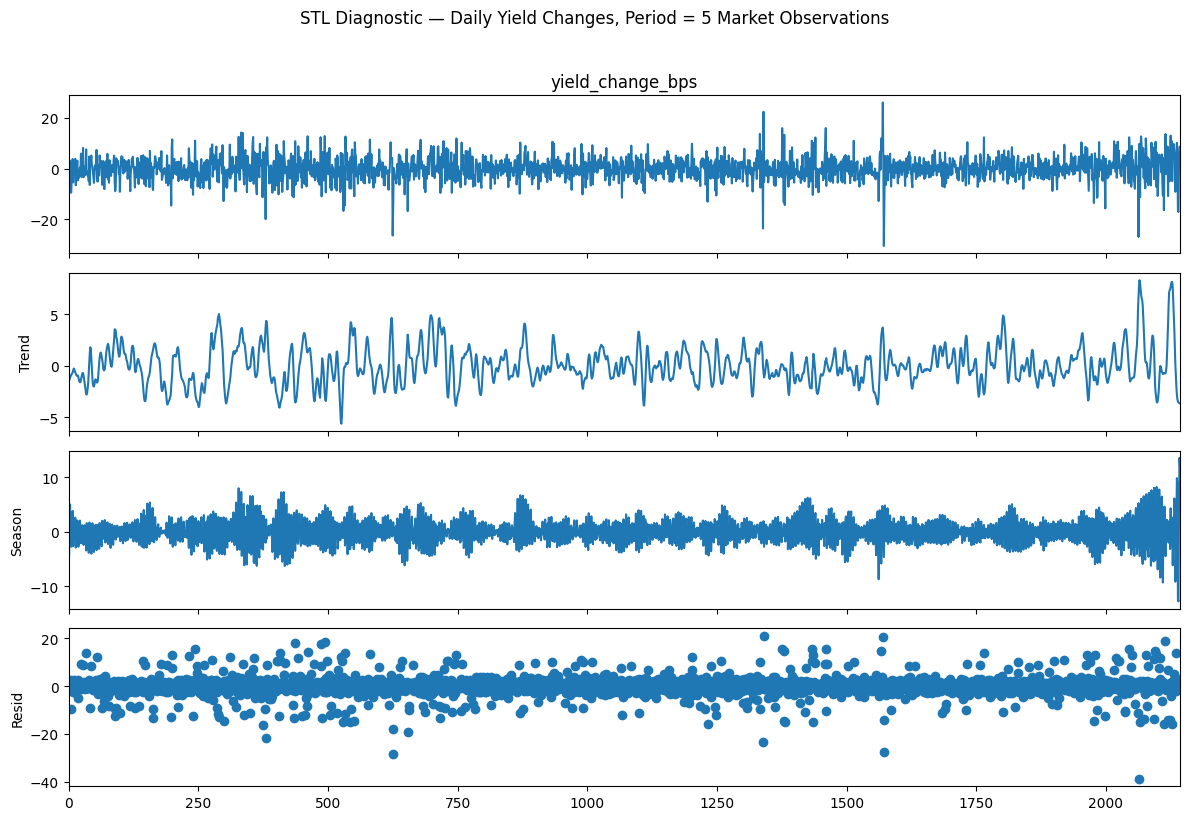

In [33]:
SEASONAL_PERIOD = 5

stl_result = STL(
    train_changes.reset_index(drop=True),
    period=SEASONAL_PERIOD,
    robust=True
).fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle(
    "STL Diagnostic — Daily Yield Changes, Period = 5 Market Observations",
    y=1.02
)

plt.tight_layout()
plt.show()

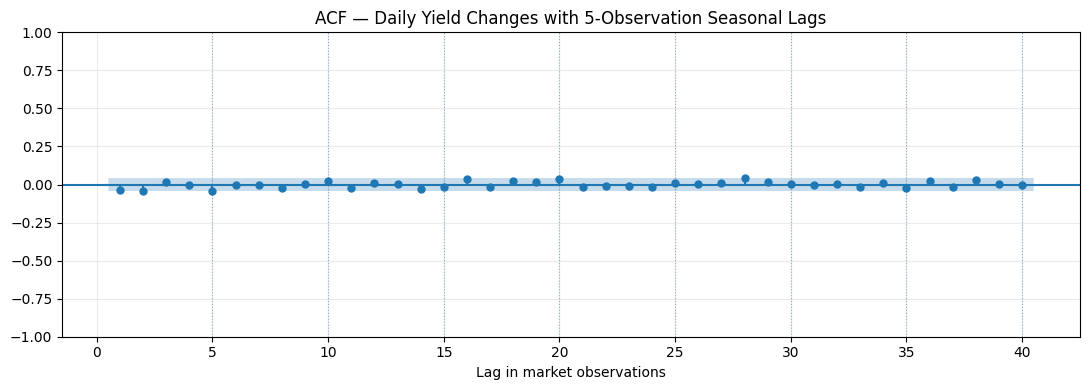

In [34]:
fig, ax = plt.subplots(figsize=(11, 4))

plot_acf(
    train_changes,
    lags=40,
    zero=False,
    ax=ax
)

for lag in range(SEASONAL_PERIOD, 41, SEASONAL_PERIOD):
    ax.axvline(
        lag,
        linestyle=":",
        linewidth=0.8,
        alpha=0.5
    )

ax.set_title(
    "ACF — Daily Yield Changes with 5-Observation Seasonal Lags"
)
ax.set_xlabel("Lag in market observations")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Seasonality Diagnostic: 5-Market-Observation Cycle

The STL decomposition was examined using a seasonal period of **5 market observations**, corresponding approximately to one trading week. The decomposition does not reveal a clear or stable weekly seasonal pattern in daily 10-year yield changes. Although the estimated seasonal component fluctuates over time, its magnitude varies substantially rather than repeating with a consistent structure. This suggests that much of the apparent variation is more likely associated with changing volatility than with deterministic weekly seasonality.

The ACF provides stronger evidence against a meaningful 5-observation seasonal cycle. At the seasonal lags of **5, 10, 15, 20, 25, 30, 35 and 40 observations**, the autocorrelations remain very close to zero and are predominantly within the confidence interval. There are therefore no repeated significant spikes at multiples of five that would normally indicate weekly seasonal dependence.

The residual component also contains several large positive and negative observations and periods of differing dispersion, indicating that substantial variation remains after the STL decomposition.

In [35]:
from statsmodels.tsa.stattools import acf

acf_values = acf(
    train_changes,
    nlags=40,
    fft=True
)

seasonal_lags = list(
    range(SEASONAL_PERIOD, 41, SEASONAL_PERIOD)
)

seasonal_acf_table = pd.DataFrame({
    "lag": seasonal_lags,
    "acf": [acf_values[lag] for lag in seasonal_lags]
})

approx_95_threshold = 1.96 / np.sqrt(len(train_changes))

seasonal_acf_table["abs_acf"] = seasonal_acf_table["acf"].abs()
seasonal_acf_table["outside_approx_95_band"] = (
    seasonal_acf_table["abs_acf"] > approx_95_threshold
)

print(
    f"Approximate 95% ACF threshold: "
    f"±{approx_95_threshold:.4f}"
)

seasonal_acf_table

Approximate 95% ACF threshold: ±0.0423


,lag,acf,abs_acf,outside_approx_95_band
0,5,-0.040311,0.040311,False
1,10,0.026072,0.026072,False
2,15,-0.015351,0.015351,False
3,20,0.034637,0.034637,False
4,25,0.007725,0.007725,False
5,30,0.005205,0.005205,False
6,35,-0.021848,0.021848,False
7,40,-0.002282,0.002282,False


#### Search a compact SARIMA grid

To avoid forcing a large seasonal specification onto financial daily data, the search is deliberately compact:

- the best ARIMA \((p,d,q)\) order is retained;
- $P,Q \in \{0,1\}$;
- $D \in \{0,1\}$;
- $s=5$.

Including \(P=Q=D=0\) allows the search to conclude that the non-seasonal ARIMA model is preferable.

This is a **diagnostic SARIMA extension**, not an assumption that seasonality must exist.

In [36]:
seasonal_candidates = list(
    product(
        [0, 1],   # P
        [0, 1],   # D
        [0, 1]    # Q
    )
)

sarima_records = []

for P, D, Q in seasonal_candidates:
    seasonal_order = (
        P,
        D,
        Q,
        SEASONAL_PERIOD
    )

    try:
        fit = fit_sarimax(
            train_level["yield_10y"],
            order=best_arima_order,
            seasonal_order=seasonal_order,
            trend="n"
        )

        sarima_records.append({
            "p": best_arima_p,
            "d": best_arima_d,
            "q": best_arima_q,
            "P": P,
            "D": D,
            "Q": Q,
            "s": SEASONAL_PERIOD,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True)
        })

    except Exception:
        sarima_records.append({
            "p": best_arima_p,
            "d": best_arima_d,
            "q": best_arima_q,
            "P": P,
            "D": D,
            "Q": Q,
            "s": SEASONAL_PERIOD,
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False
        })

sarima_selection = (
    pd.DataFrame(sarima_records)
    .dropna(subset=["AIC"])
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

sarima_selection

,p,d,q,P,D,Q,s,AIC,BIC,converged
0,2,1,2,0,0,0,5,-7061.238945,-7032.886802,True
1,2,1,2,1,0,1,5,-7058.736511,-7019.043511,True
2,2,1,2,1,0,0,5,-7057.945290,-7023.922719,True
3,2,1,2,0,0,1,5,-7057.774050,-7023.751479,True
4,2,1,2,1,1,1,5,-7012.758431,-6973.081775,False
5,2,1,2,0,1,1,5,-7011.238701,-6977.230138,False
6,2,1,2,1,1,0,5,-6433.382126,-6399.373564,False
7,2,1,2,0,1,0,5,-5623.019232,-5594.678764,False


In [37]:
best_P = int(sarima_selection.loc[0, "P"])
best_D = int(sarima_selection.loc[0, "D"])
best_Q = int(sarima_selection.loc[0, "Q"])

best_seasonal_order = (
    best_P,
    best_D,
    best_Q,
    SEASONAL_PERIOD
)

print("Non-seasonal order:", best_arima_order)
print("Selected seasonal order:", best_seasonal_order)

if (best_P, best_D, best_Q) == (0, 0, 0):
    print(
        "AIC selected no seasonal terms. "
        "The SARIMA search therefore provides no AIC-based reason "
        "to extend the ARIMA model with a 5-observation seasonal component."
    )

sarima_fit = fit_sarimax(
    train_level["yield_10y"],
    order=best_arima_order,
    seasonal_order=best_seasonal_order,
    trend="n"
)

print(sarima_fit.summary())

Non-seasonal order: (2, 1, 2)
Selected seasonal order: (0, 0, 0, 5)
AIC selected no seasonal terms. The SARIMA search therefore provides no AIC-based reason to extend the ARIMA model with a 5-observation seasonal component.
                               SARIMAX Results                                
Dep. Variable:              yield_10y   No. Observations:                 2145
Model:               SARIMAX(2, 1, 2)   Log Likelihood                3535.619
Date:                Sat, 29 Aug 2026   AIC                          -7061.239
Time:                        17:22:59   BIC                          -7032.887
Sample:                             0   HQIC                         -7050.865
                               - 2145                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

#### SARIMA Seasonality Check

The ACF of daily yield changes shows no statistically meaningful autocorrelation at the proposed **5-market-observation seasonal lags**. Using an approximate 95% threshold of **±0.0423**, the autocorrelations at lags 5, 10, 15, 20, 25, 30, 35 and 40 all remain within the confidence band. This provides little evidence of a persistent weekly seasonal pattern.

The SARIMA model search supports the same conclusion. With the non-seasonal order fixed at **ARIMA(2,1,2)**, AIC selected the seasonal specification **(0,0,0,5)**, meaning that no seasonal AR, differencing or MA terms were required. The resulting model is therefore equivalent to the previously selected **ARIMA(2,1,2)**, with an AIC of **−7061.24** and BIC of **−7032.89**.

Both the ACF diagnostics and model selection provide **no evidence that adding a 5-observation seasonal component improves the model**. A seasonal SARIMA extension is therefore not justified for these daily yield data.

## Compare all conditional-mean forecasts

All six forecasts are now compared on the same holdout period and on the same original yield-level scale.

The main ranking metrics are:

- **MAE** — average absolute forecast error;
- **RMSE** — gives more weight to larger forecast errors.

Both are reported in percentage points and basis points.

In [38]:
model_names = {
    "Random Walk": "Random Walk",
    "AR": f"AR({best_ar_p})",
    "MA": f"MA({best_ma_q})",
    "ARMA": f"ARMA({best_arma_p},{best_arma_q})",
    "ARIMA": f"ARIMA{best_arima_order}",
}

forecast_dict = {
    "Random Walk": rw_forecast,
    "AR": ar_forecast,
    "MA": ma_forecast,
    "ARMA": arma_forecast,
    "ARIMA": arima_forecast,
}

metric_rows = []

for family, forecast in forecast_dict.items():
    metrics = forecast_metrics(
        test_level["yield_10y"],
        forecast
    )

    metric_rows.append({
        "family": family,
        "selected_model": model_names[family],
        **metrics
    })

forecast_comparison = (
    pd.DataFrame(metric_rows)
    .sort_values("RMSE_bps")
    .reset_index(drop=True)
)

forecast_comparison


,family,selected_model,MAE_percentage_points,RMSE_percentage_points,MAE_bps,RMSE_bps
0,Random Walk,Random Walk,0.421998,0.473040,42.199833,47.303980
1,ARIMA,"ARIMA(2, 1, 2)",0.422580,0.473187,42.258042,47.318736
2,AR,AR(2),0.421265,0.476546,42.126463,47.654583
3,MA,MA(2),0.421225,0.476554,42.122530,47.655450
4,ARMA,"ARMA(2,2)",0.424404,0.476980,42.440417,47.698000


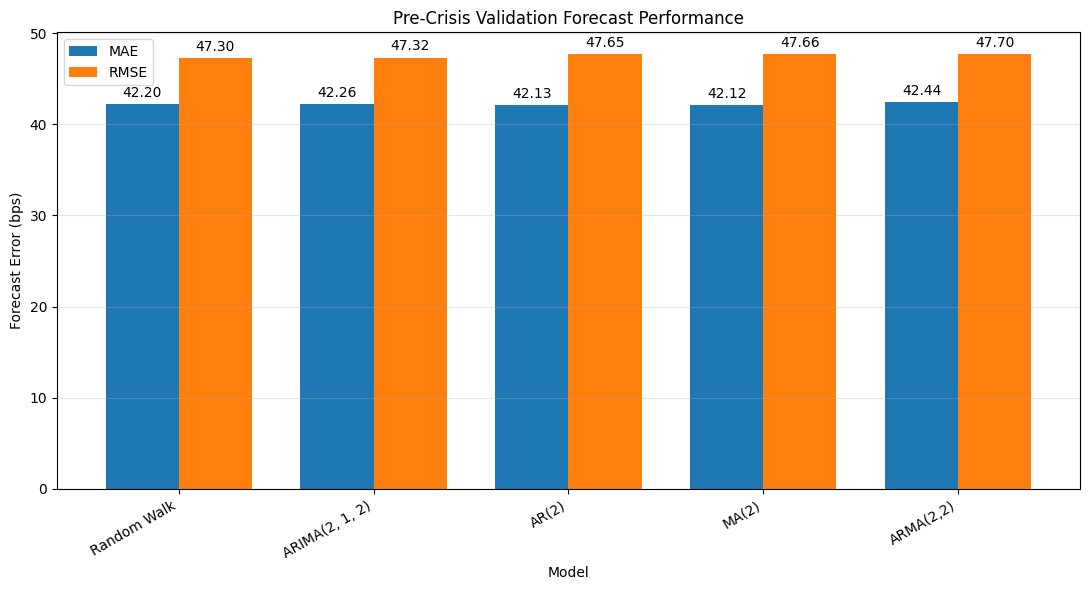

In [39]:
# Visual comparison of pre-crisis validation performance

plot_data = (
    forecast_comparison
    .set_index("selected_model")[["MAE_bps", "RMSE_bps"]]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

ax.set_title("Pre-Crisis Validation Forecast Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Forecast Error (bps)")

plt.xticks(rotation=30, ha="right")
plt.legend(["MAE", "RMSE"])
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()


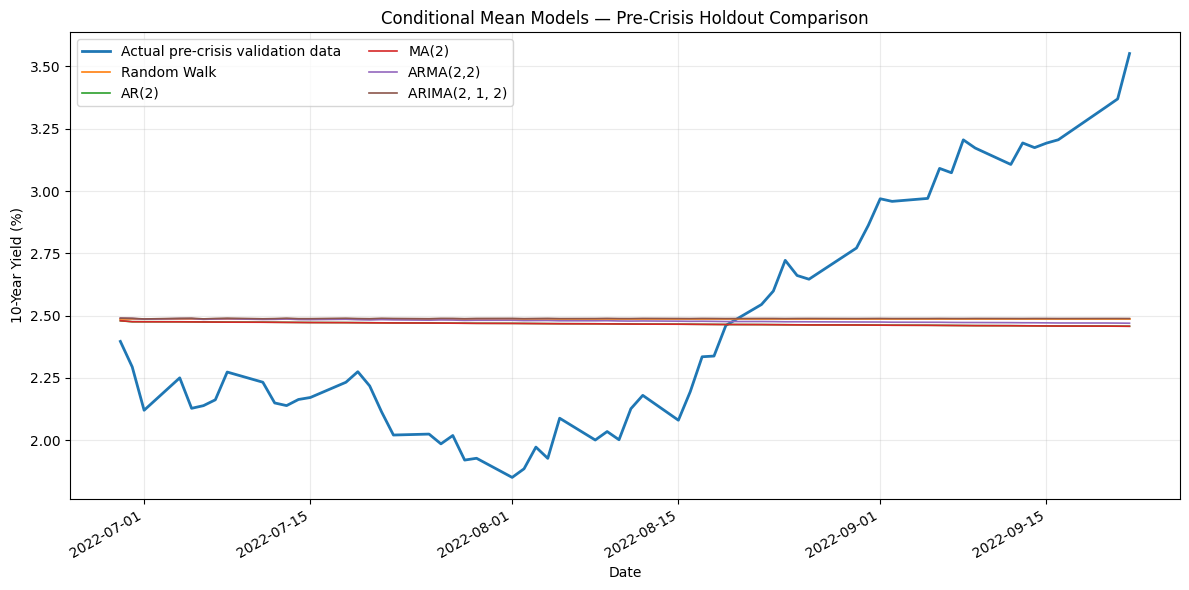

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    test_level["date"],
    test_level["yield_10y"],
    linewidth=2,
    label="Actual pre-crisis validation data"
)

for family, forecast in forecast_dict.items():
    ax.plot(
        test_level["date"],
        forecast,
        linewidth=1.2,
        label=model_names[family]
    )

ax.set_title("Conditional Mean Models — Pre-Crisis Holdout Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("10-Year Yield (%)")
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Compare residual autocorrelation

For each fitted model, the Ljung–Box p-value at lag 20 is reported below. This is a compact check of whether substantial linear serial dependence remains after fitting.

This table should be interpreted alongside the full residual plots rather than used as the sole selection criterion.

In [41]:
def lb_pvalue_at(lb_table, lag):
    if lag in lb_table.index:
        return float(lb_table.loc[lag, "lb_pvalue"])
    return np.nan


residual_summary = pd.DataFrame([
    {
        "model": "Random Walk",
        "LjungBox_p_lag20": lb_pvalue_at(rw_ljungbox, 20)
    },
    {
        "model": f"AR({best_ar_p})",
        "LjungBox_p_lag20": lb_pvalue_at(ar_ljungbox, 20)
    },
    {
        "model": f"MA({best_ma_q})",
        "LjungBox_p_lag20": lb_pvalue_at(ma_ljungbox, 20)
    },
    {
        "model": f"ARMA({best_arma_p},{best_arma_q})",
        "LjungBox_p_lag20": lb_pvalue_at(arma_ljungbox, 20)
    },
    {
        "model": f"ARIMA{best_arima_order}",
        "LjungBox_p_lag20": lb_pvalue_at(arima_ljungbox, 20)
    }
])

residual_summary["passes_5pct_lag20"] = (
    residual_summary["LjungBox_p_lag20"] >= 0.05
)

residual_summary

,model,LjungBox_p_lag20,passes_5pct_lag20
0,Random Walk,0.196427,True
1,AR(2),0.571903,True
2,MA(2),0.559219,True
3,"ARMA(2,2)",0.890212,True
4,"ARIMA(2, 1, 2)",0.890131,True


## Pre-Crisis Rolling Forecast

The fixed-origin validation forecasts above are complemented by an **expanding-window, one-step-ahead rolling forecast** using only pre-crisis observations.

At each validation date, the model is re-estimated using observations available up to the previous market day. No crisis-period observation enters this rolling evaluation.

This rolling exercise is used to compare forecast performance under realistic one-step-ahead updating. It is **not** used for the final crisis counterfactual, because updating a model with realised crisis observations would contaminate the no-crisis forecast.


In [45]:
def rolling_forecast(
    df: pd.DataFrame,
    train_len: int,
    horizon: int,
    window: int,
    method: str
) -> list:
    """
    Expanding-window rolling forecast on the yield level.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain a 'yield_10y' column.
    train_len : int
        Number of observations available before the test period.
    horizon : int
        Number of test observations to forecast.
    window : int
        Number of observations forecast at each rolling origin.
        Use window=1 for one-step-ahead rolling evaluation.
    method : str
        One of: 'Random Walk', 'AR', 'MA', 'ARMA', 'ARIMA'.

    Returns
    -------
    list
        Forecasts on the original yield-level scale.
    """

    if window < 1:
        raise ValueError("window must be at least 1.")

    total_len = min(train_len + horizon, len(df))
    predictions = []

    for i in range(train_len, total_len, window):
        steps = min(window, total_len - i)

        # Only observations available at the current forecast origin.
        level_history = (
            df["yield_10y"]
            .iloc[:i]
            .astype(float)
            .copy()
        )

        last_level = float(level_history.iloc[-1])

        if method == "Random Walk":
            block_forecast = np.repeat(
                last_level,
                steps
            )

        elif method in {"AR", "MA", "ARMA"}:
            # Recompute changes from the available level history so that
            # no future observation enters the model at this origin.
            change_history_bps = (
                level_history
                .diff()
                .dropna()
                * 100
            )

            if method == "AR":
                order = (best_ar_p, 0, 0)

            elif method == "MA":
                order = (0, 0, best_ma_q)

            else:
                order = (
                    best_arma_p,
                    0,
                    best_arma_q
                )

            fit = fit_sarimax(
                change_history_bps,
                order=order,
                trend="c"
            )

            change_forecast_bps = np.asarray(
                fit.get_forecast(
                    steps=steps
                ).predicted_mean,
                dtype=float
            )

            block_forecast = (
                last_level
                + np.cumsum(
                    change_forecast_bps
                ) / 100
            )

        elif method == "ARIMA":
            fit = fit_sarimax(
                level_history,
                order=best_arima_order,
                trend="n"
            )

            block_forecast = np.asarray(
                fit.get_forecast(
                    steps=steps
                ).predicted_mean,
                dtype=float
            )

        else:
            raise ValueError(
                "method must be one of: "
                "'Random Walk', 'AR', 'MA', "
                "'ARMA', 'ARIMA'."
            )

        predictions.extend(
            np.asarray(
                block_forecast,
                dtype=float
            ).tolist()
        )

    return predictions[:horizon]

ROLLING_WINDOW = 1

rolling_forecast_dict = {
    "Random Walk": rolling_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        ROLLING_WINDOW,
        "Random Walk"
    ),

    "AR": rolling_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        ROLLING_WINDOW,
        "AR"
    ),

    "MA": rolling_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        ROLLING_WINDOW,
        "MA"
    ),

    "ARMA": rolling_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        ROLLING_WINDOW,
        "ARMA"
    ),

    "ARIMA": rolling_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        ROLLING_WINDOW,
        "ARIMA"
    ),
}

rolling_model_names = {
    "Random Walk": "Random Walk",
    "AR": f"AR({best_ar_p})",
    "MA": f"MA({best_ma_q})",
    "ARMA": f"ARMA({best_arma_p},{best_arma_q})",
    "ARIMA": f"ARIMA{best_arima_order}",
}

print(
    f"Completed rolling forecasts with "
    f"window = {ROLLING_WINDOW} observation."
)

Completed rolling forecasts with window = 1 observation.


In [126]:
def fixed_origin_forecast(
    df: pd.DataFrame,
    train_len: int,
    horizon: int,
    method: str
) -> list:

    # Use training data only
    level_history = (
        df["yield_10y"]
        .iloc[:train_len]
        .astype(float)
        .copy()
    )

    last_level = float(level_history.iloc[-1])

    # Random Walk
    if method == "Random Walk":

        forecast = np.repeat(
            last_level,
            horizon
        )

    # AR / MA / ARMA
    elif method in {"AR", "MA", "ARMA"}:

        change_history_bps = (
            level_history
            .diff()
            .dropna()
            * 100
        )

        if method == "AR":
            order = (best_ar_p, 0, 0)

        elif method == "MA":
            order = (0, 0, best_ma_q)

        else:
            order = (
                best_arma_p,
                0,
                best_arma_q
            )

        fit = fit_sarimax(
            change_history_bps,
            order=order,
            trend="c"
        )

        change_forecast_bps = np.asarray(
            fit.get_forecast(
                steps=horizon
            ).predicted_mean,
            dtype=float
        )

        forecast = (
            last_level
            + np.cumsum(
                change_forecast_bps
            ) / 100
        )

    # ARIMA
    elif method == "ARIMA":

        fit = fit_sarimax(
            level_history,
            order=best_arima_order,
            trend="n"
        )

        forecast = np.asarray(
            fit.get_forecast(
                steps=horizon
            ).predicted_mean,
            dtype=float
        )

    else:
        raise ValueError(
            "method must be one of: "
            "'Random Walk', 'AR', 'MA', "
            "'ARMA', 'ARIMA'."
        )

    return np.asarray(
        forecast,
        dtype=float
    ).tolist()
    
ROLLING_WINDOW = 1

# FIXED-ORIGIN 60-DAY FORECAST
# No observations from the test period are fed back into models

fixed_forecast_dict = {
    "Random Walk": fixed_origin_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        "Random Walk"
    ),

    "AR": fixed_origin_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        "AR"
    ),

    "MA": fixed_origin_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        "MA"
    ),

    "ARMA": fixed_origin_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        "ARMA"
    ),

    "ARIMA": fixed_origin_forecast(
        pre_crisis,
        len(train_level),
        HORIZON,
        "ARIMA"
    ),
}


fixed_model_names = {
    "Random Walk": "Random Walk",
    "AR": f"AR({best_ar_p})",
    "MA": f"MA({best_ma_q})",
    "ARMA": f"ARMA({best_arma_p},{best_arma_q})",
    "ARIMA": f"ARIMA{best_arima_order}",
}


print(
    f"Completed fixed-origin forecasts for "
    f"{HORIZON} unseen validation observations."
)

Completed fixed-origin forecasts for 60 unseen validation observations.


In [127]:
rolling_metric_rows = []

for family, forecast in rolling_forecast_dict.items():
    metrics = forecast_metrics(
        test_level["yield_10y"],
        forecast
    )

    rolling_metric_rows.append({
        "family": family,
        "selected_model": rolling_model_names[family],
        **metrics
    })
 
rolling_forecast_comparison = (
    pd.DataFrame(rolling_metric_rows)
    .sort_values("RMSE_bps")
    .reset_index(drop=True)
)

rolling_forecast_comparison

,family,selected_model,MAE_percentage_points,RMSE_percentage_points,MAE_bps,RMSE_bps
0,Random Walk,Random Walk,0.070357,0.085086,7.035667,8.508585
1,ARMA,"ARMA(2,2)",0.070936,0.085467,7.093629,8.546667
2,MA,MA(2),0.070692,0.085840,7.069181,8.584029
3,AR,AR(2),0.070719,0.085841,7.071897,8.584067
4,ARIMA,"ARIMA(2, 1, 2)",0.071101,0.086037,7.110109,8.603661


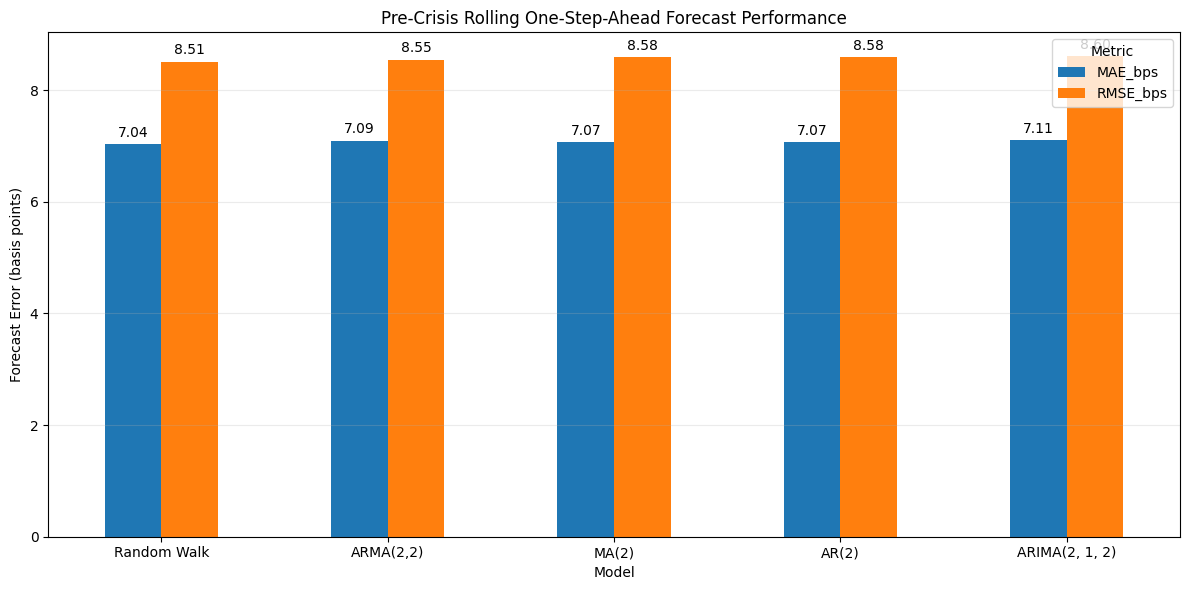

In [128]:
# Pre-crisis rolling-forecast MAE and RMSE comparison

rolling_plot_data = (
    rolling_forecast_comparison
    .set_index("selected_model")[["MAE_bps", "RMSE_bps"]]
)

ax = rolling_plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

ax.set_title("Pre-Crisis Rolling One-Step-Ahead Forecast Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Forecast Error (basis points)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


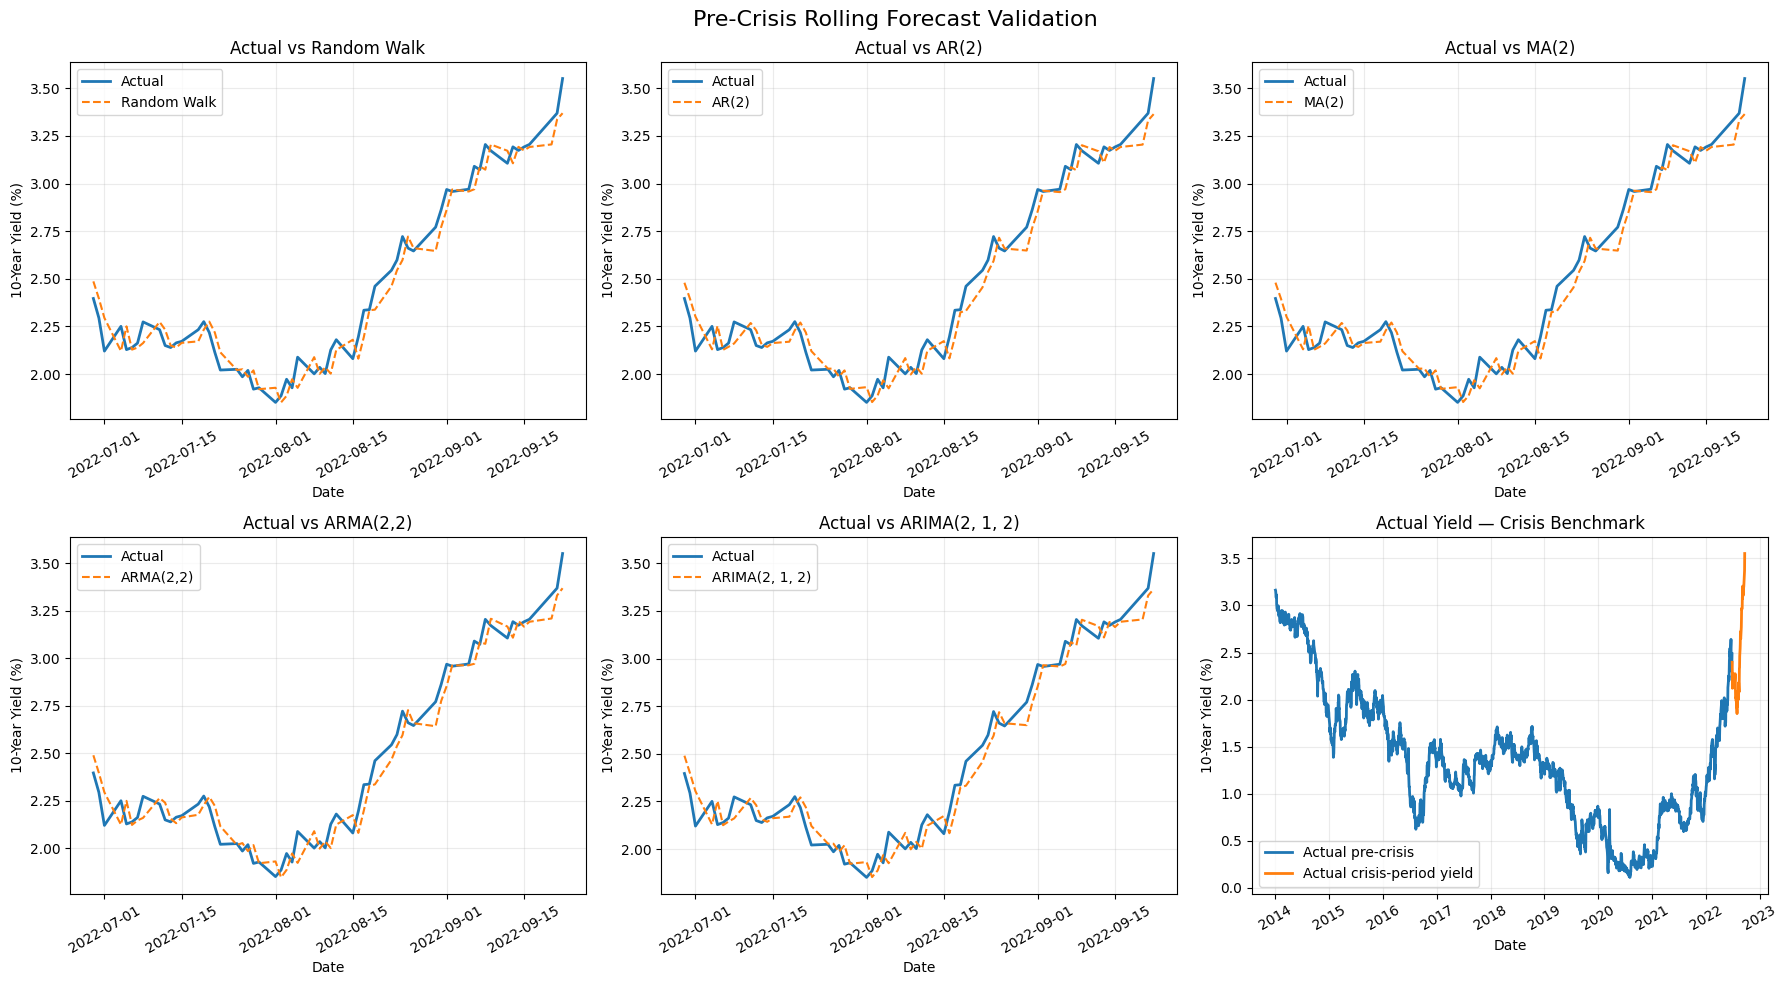

In [129]:
# Actual pre-crisis yields versus rolling one-step-ahead forecasts

# Pre-crisis rolling forecast comparison:
# 5 model panels + 1 actual crisis benchmark panel

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

axes = axes.flatten()

# Actual pre-crisis validation data vs each model

for ax, (family, forecast) in zip(
    axes[:5],
    rolling_forecast_dict.items()
):
    
    # Actual validation data
    ax.plot(
        test_level["date"],
        test_level["yield_10y"],
        linewidth=2,
        label="Actual"
    )
    
    # Individual model forecast
    ax.plot(
        test_level["date"],
        forecast,
        linewidth=1.5,
        linestyle="--",
        label=rolling_model_names[family]
    )
    
    ax.set_title(
        f"Actual vs {rolling_model_names[family]}"
    )
    
    ax.set_xlabel("Date")
    ax.set_ylabel("10-Year Yield (%)")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(
        axis="x",
        rotation=30
    )


# Actual observed crisis-period benchmark

ax = axes[5]

# Pre-crisis actual observations
ax.plot(
    train_level["date"],
    train_level["yield_10y"],
    linewidth=2,
    label="Actual pre-crisis"
)

# Actual validation / crisis observations
ax.plot(
    test_level["date"],
    test_level["yield_10y"],
    linewidth=2,
    label="Actual crisis-period yield"
)

ax.set_title(
    "Actual Yield — Crisis Benchmark"
)

ax.set_xlabel("Date")
ax.set_ylabel("10-Year Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
ax.tick_params(
    axis="x",
    rotation=30
)

plt.suptitle(
    "Pre-Crisis Rolling Forecast Validation",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [130]:
# Compare fixed-origin and rolling-origin forecast accuracy

fixed_origin_metrics = (
    forecast_comparison
    .query("family != 'SARIMA'")
    [
        [
            "family",
            "selected_model",
            "MAE_bps",
            "RMSE_bps"
        ]
    ]
    .rename(
        columns={
            "MAE_bps": "fixed_MAE_bps",
            "RMSE_bps": "fixed_RMSE_bps"
        }
    )
)

rolling_origin_metrics = (
    rolling_forecast_comparison
    [
        [
            "family",
            "MAE_bps",
            "RMSE_bps"
        ]
    ]
    .rename(
        columns={
            "MAE_bps": "rolling_MAE_bps",
            "RMSE_bps": "rolling_RMSE_bps"
        }
    )
)

fixed_vs_rolling = (
    fixed_origin_metrics
    .merge(
        rolling_origin_metrics,
        on="family",
        how="inner"
    )
    .sort_values("rolling_RMSE_bps")
    .reset_index(drop=True)
)

fixed_vs_rolling

,family,selected_model,fixed_MAE_bps,fixed_RMSE_bps,rolling_MAE_bps,rolling_RMSE_bps
0,Random Walk,Random Walk,42.199833,47.303980,7.035667,8.508585
1,ARMA,"ARMA(2,2)",42.440417,47.698000,7.093629,8.546667
2,MA,MA(2),42.122530,47.655450,7.069181,8.584029
3,AR,AR(2),42.126463,47.654583,7.071897,8.584067
4,ARIMA,"ARIMA(2, 1, 2)",42.258042,47.318736,7.110109,8.603661


In [131]:
# Refit selected specifications on the complete pre-crisis sample

pre_crisis_level = pre_crisis["yield_10y"].astype(float)
pre_crisis_changes_bps = (
    pre_crisis_level
    .diff()
    .dropna()
    * 100
)

cf_horizon = len(counterfactual_window)
cf_last_level = float(pre_crisis_level.iloc[-1])

# Random Walk
cf_rw = np.repeat(cf_last_level, cf_horizon)

# AR
cf_ar_fit = fit_sarimax(
    pre_crisis_changes_bps,
    order=(best_ar_p, 0, 0),
    trend="c"
)
cf_ar = forecast_changes_to_level(
    cf_ar_fit,
    cf_last_level,
    cf_horizon
)

# MA
cf_ma_fit = fit_sarimax(
    pre_crisis_changes_bps,
    order=(0, 0, best_ma_q),
    trend="c"
)
cf_ma = forecast_changes_to_level(
    cf_ma_fit,
    cf_last_level,
    cf_horizon
)

# ARMA
cf_arma_fit = fit_sarimax(
    pre_crisis_changes_bps,
    order=(best_arma_p, 0, best_arma_q),
    trend="c"
)
cf_arma = forecast_changes_to_level(
    cf_arma_fit,
    cf_last_level,
    cf_horizon
)

# ARIMA
cf_arima_fit = fit_sarimax(
    pre_crisis_level,
    order=best_arima_order,
    trend="n"
)
cf_arima = np.asarray(
    cf_arima_fit.get_forecast(steps=cf_horizon).predicted_mean,
    dtype=float
)

counterfactual_forecasts = {
    "Random Walk": cf_rw,
    f"AR({best_ar_p})": cf_ar,
    f"MA({best_ma_q})": cf_ma,
    f"ARMA({best_arma_p},{best_arma_q})": cf_arma,
    f"ARIMA{best_arima_order}": cf_arima,
}


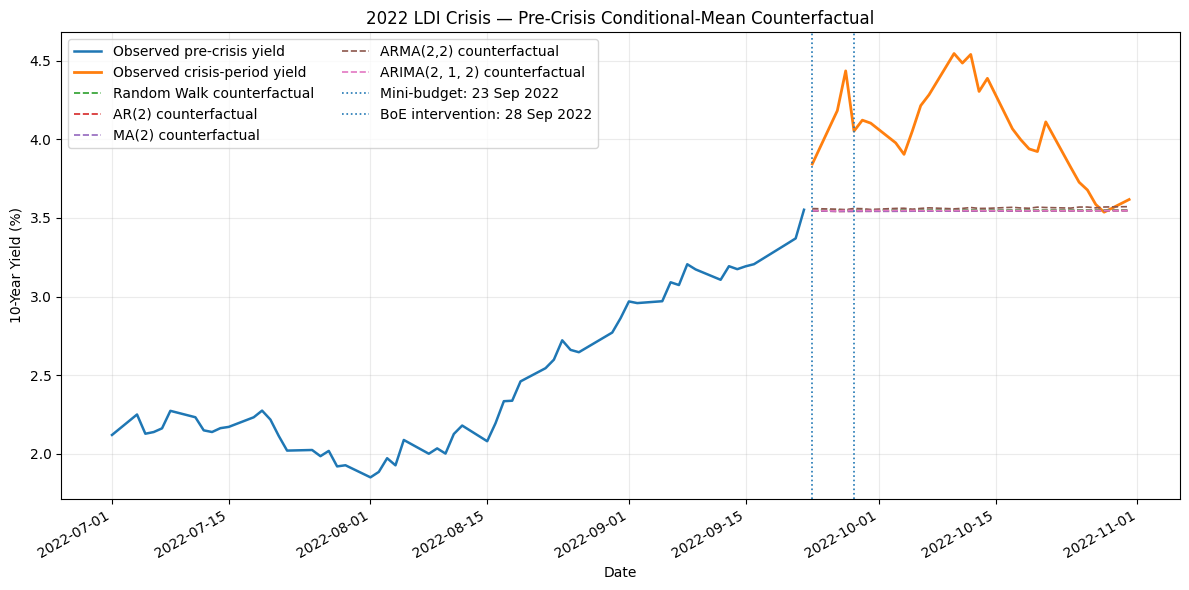

In [132]:
fig, ax = plt.subplots(figsize=(12, 6))

# Show a short pre-crisis history for context.
context = model_data.loc[
    (model_data["date"] >= pd.Timestamp("2022-07-01"))
    & (model_data["date"] < CRISIS_START)
]

ax.plot(
    context["date"],
    context["yield_10y"],
    linewidth=1.8,
    label="Observed pre-crisis yield"
)

ax.plot(
    counterfactual_window["date"],
    counterfactual_window["yield_10y"],
    linewidth=2,
    label="Observed crisis-period yield"
)

for name, forecast in counterfactual_forecasts.items():
    ax.plot(
        counterfactual_window["date"],
        forecast,
        linestyle="--",
        linewidth=1.2,
        label=f"{name} counterfactual"
    )

ax.axvline(
    CRISIS_START,
    linestyle=":",
    linewidth=1.2,
    label="Mini-budget: 23 Sep 2022"
)

ax.axvline(
    pd.Timestamp("2022-09-28"),
    linestyle=":",
    linewidth=1.2,
    label="BoE intervention: 28 Sep 2022"
)

ax.set_title("2022 LDI Crisis — Pre-Crisis Conditional-Mean Counterfactual")
ax.set_xlabel("Date")
ax.set_ylabel("10-Year Yield (%)")
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Counterfactual interpretation

The dashed paths represent forecasts generated entirely from **pre-crisis information**. They provide a baseline for how the 10-year gilt yield might have evolved if its pre-crisis conditional-mean dynamics had continued.

The observed crisis-period series can be compared with these paths to measure the size and timing of the divergence. The difference should be interpreted as a **model-based counterfactual gap**, not as a formal causal estimate of the mini-budget or the LDI crisis.


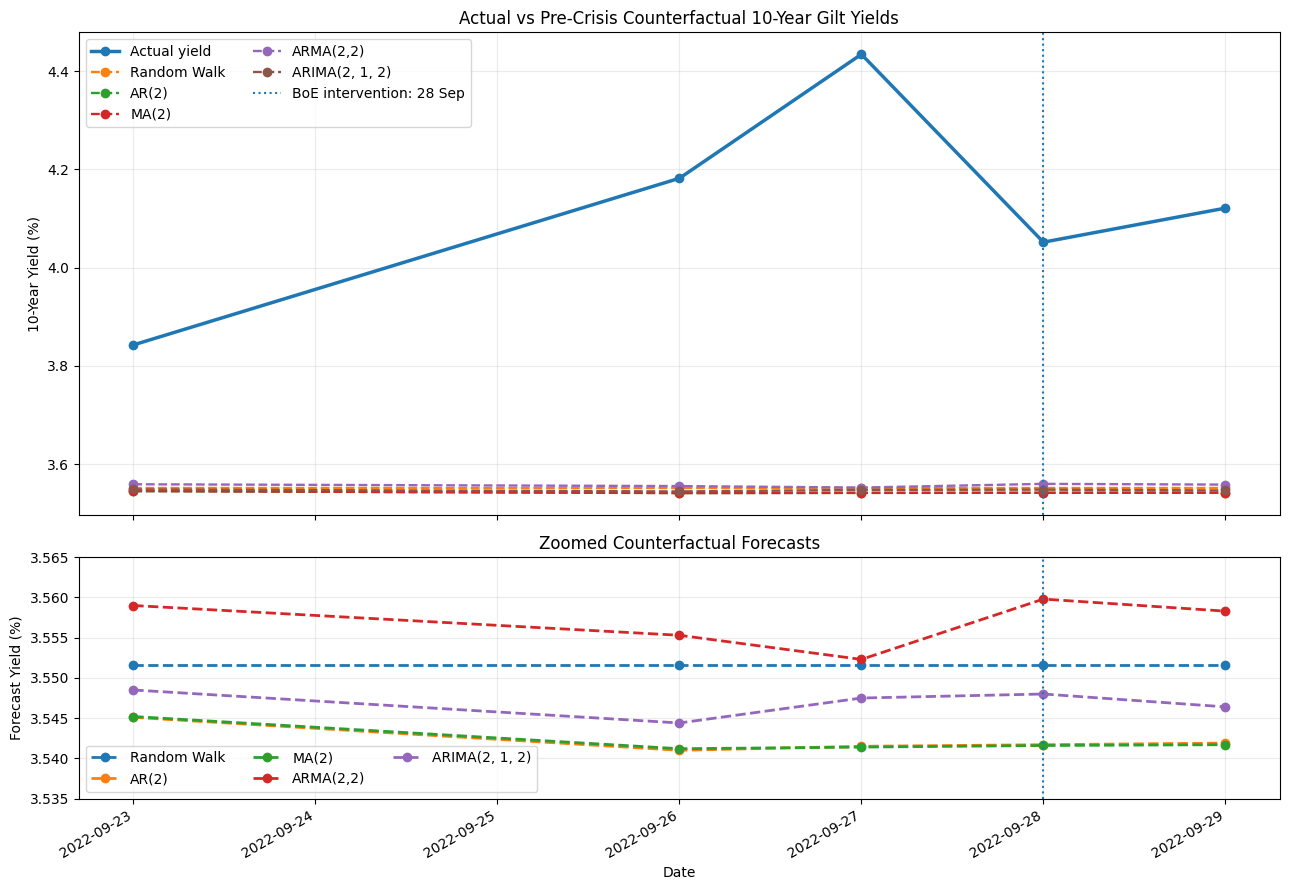

In [133]:
plot_table = comparison_table.copy()

model_columns = [
    "Random Walk",
    "AR(2)",
    "MA(2)",
    "ARMA(2,2)",
    "ARIMA(2, 1, 2)"
]


fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 9),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)


ax = axes[0]

ax.plot(
    plot_table["date"],
    plot_table["Actual Yield (%)"],
    marker="o",
    linewidth=2.5,
    label="Actual yield"
)

for model in model_columns:
    ax.plot(
        plot_table["date"],
        plot_table[model],
        marker="o",
        linestyle="--",
        linewidth=1.7,
        label=model
    )

ax.axvline(
    pd.Timestamp("2022-09-28"),
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.set_ylabel("10-Year Yield (%)")

ax.set_title(
    "Actual vs Pre-Crisis Counterfactual 10-Year Gilt Yields"
)

ax.grid(alpha=0.25)
ax.legend(
    ncol=2
)

ax = axes[1]

for model in model_columns:
    ax.plot(
        plot_table["date"],
        plot_table[model],
        marker="o",
        linestyle="--",
        linewidth=2,
        label=model
    )

ax.axvline(
    pd.Timestamp("2022-09-28"),
    linestyle=":",
    linewidth=1.5
)

# Zoom into the forecast range
ax.set_ylim(
    3.535,
    3.565
)

ax.set_ylabel("Forecast Yield (%)")
ax.set_xlabel("Date")

ax.set_title(
    "Zoomed Counterfactual Forecasts"
)

ax.grid(alpha=0.25)
ax.legend(
    ncol=3
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [134]:
# 22–29 SEPTEMBER:
# ACTUAL + 5 FIXED COUNTERFACTUALS + 5 ROLLING FORECASTS

START_DATE = pd.Timestamp("2022-09-22")
FORECAST_START = pd.Timestamp("2022-09-23")
END_DATE = pd.Timestamp("2022-09-29")



# Data available up to 29 September

sep_data = (
    model_data.loc[
        model_data["date"] <= END_DATE,
        ["date", "yield_10y"]
    ]
    .copy()
    .reset_index(drop=True)
)


# Number of observations available through 22 September
train_len_sep = len(
    sep_data.loc[
        sep_data["date"] <= START_DATE
    ]
)


# Number of market observations from 23–29 September
horizon_sep = len(
    sep_data.loc[
        sep_data["date"].between(
            FORECAST_START,
            END_DATE
        )
    ]
)

print("Training observations:", train_len_sep)
print("Forecast observations:", horizon_sep)

Training observations: 2205
Forecast observations: 5


In [138]:
# ROLLING FORECASTS: 23–29 SEPTEMBER

ROLLING_WINDOW_EVENT = 1

event_rolling_forecasts = {
    "Random Walk": rolling_forecast(
        sep_data,
        train_len_sep,
        horizon_sep,
        ROLLING_WINDOW_EVENT,
        "Random Walk"
    ),

    "AR": rolling_forecast(
        sep_data,
        train_len_sep,
        horizon_sep,
        ROLLING_WINDOW_EVENT,
        "AR"
    ),

    "MA": rolling_forecast(
        sep_data,
        train_len_sep,
        horizon_sep,
        ROLLING_WINDOW_EVENT,
        "MA"
    ),

    "ARMA": rolling_forecast(
        sep_data,
        train_len_sep,
        horizon_sep,
        ROLLING_WINDOW_EVENT,
        "ARMA"
    ),

    "ARIMA": rolling_forecast(
        sep_data,
        train_len_sep,
        horizon_sep,
        ROLLING_WINDOW_EVENT,
        "ARIMA"
    )
}

### Save model-selection and forecast results

In [139]:
# BUILD COMPARISON TABLE

event_dates = (
    sep_data.loc[
        sep_data["date"].between(
            FORECAST_START,
            END_DATE
        ),
        "date"
    ]
    .reset_index(drop=True)
)

actual_event = (
    sep_data.loc[
        sep_data["date"].between(
            FORECAST_START,
            END_DATE
        ),
        "yield_10y"
    ]
    .reset_index(drop=True)
)


# Fixed-origin counterfactual mask
fixed_mask = counterfactual_window["date"].between(
    FORECAST_START,
    END_DATE
)


comparison_event = pd.DataFrame({
    "Date": event_dates,
    "Actual Yield (%)": actual_event,

    # Random Walk
    "Random Walk Fixed": np.asarray(
        counterfactual_forecasts["Random Walk"]
    )[fixed_mask.to_numpy()],

    "Random Walk Rolling": np.asarray(
        event_rolling_forecasts["Random Walk"]
    ),

    # AR(2)
    "AR(2) Fixed": np.asarray(
        counterfactual_forecasts["AR(2)"]
    )[fixed_mask.to_numpy()],

    "AR(2) Rolling": np.asarray(
        event_rolling_forecasts["AR"]
    ),

    # MA(2)
    "MA(2) Fixed": np.asarray(
        counterfactual_forecasts["MA(2)"]
    )[fixed_mask.to_numpy()],

    "MA(2) Rolling": np.asarray(
        event_rolling_forecasts["MA"]
    ),

    # ARMA(2,2)
    "ARMA(2,2) Fixed": np.asarray(
        counterfactual_forecasts["ARMA(2,2)"]
    )[fixed_mask.to_numpy()],

    "ARMA(2,2) Rolling": np.asarray(
        event_rolling_forecasts["ARMA"]
    ),

    # ARIMA(2,1,2)
    "ARIMA(2,1,2) Fixed": np.asarray(
        counterfactual_forecasts["ARIMA(2, 1, 2)"]
    )[fixed_mask.to_numpy()],

    "ARIMA(2,1,2) Rolling": np.asarray(
        event_rolling_forecasts["ARIMA"]
    )
})


comparison_event.round(4)

,Date,Actual Yield (%),Random Walk Fixed,Random Walk Rolling,AR(2) Fixed,AR(2) Rolling,MA(2) Fixed,MA(2) Rolling,"ARMA(2,2) Fixed","ARMA(2,2) Rolling","ARIMA(2,1,2) Fixed","ARIMA(2,1,2) Rolling"
0,2022-09-23,3.8426,3.5516,3.5516,3.5451,3.5451,3.5452,3.5452,3.5590,3.5590,3.5485,3.5485
1,2022-09-26,4.1817,3.5516,3.8426,3.5410,3.8326,3.5412,3.8331,3.5553,3.8373,3.5444,3.8315
2,2022-09-27,4.4341,3.5516,4.1817,3.5415,4.1788,3.5414,4.1791,3.5523,4.1739,3.5475,4.1761
3,2022-09-28,4.0517,3.5516,4.4341,3.5417,4.4400,3.5416,4.4394,3.5598,4.4559,3.5480,4.4497
4,2022-09-29,4.1210,3.5516,4.0517,3.5419,4.0482,3.5417,4.0479,3.5583,4.0532,3.5464,4.0530


In [140]:
OUTPUT_DIR = Path("outputs") / "conditional_mean"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ar_selection.to_csv(
    OUTPUT_DIR / "ar_order_selection.csv",
    index=False
)

ma_selection.to_csv(
    OUTPUT_DIR / "ma_order_selection.csv",
    index=False
)

arma_selection.to_csv(
    OUTPUT_DIR / "arma_order_selection.csv",
    index=False
)

arima_selection.to_csv(
    OUTPUT_DIR / "arima_order_selection.csv",
    index=False
)

sarima_selection.to_csv(
    OUTPUT_DIR / "sarima_order_selection.csv",
    index=False
)

seasonal_acf_table.to_csv(
    OUTPUT_DIR / "seasonal_acf_diagnostic.csv",
    index=False
)

forecast_comparison.to_csv(
    OUTPUT_DIR / "pre_crisis_validation_forecast_comparison.csv",
    index=False
)

rolling_forecast_comparison.to_csv(
    OUTPUT_DIR / "pre_crisis_rolling_forecast_comparison.csv",
    index=False
)

residual_summary.to_csv(
    OUTPUT_DIR / "residual_ljungbox_summary.csv",
    index=False
)

validation_output = test_level[
    ["date", "yield_10y"]
].copy()

for family, forecast in forecast_dict.items():
    column_name = (
        family
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "_")
    )
    validation_output[f"forecast_{column_name}"] = forecast

validation_output.to_csv(
    OUTPUT_DIR / "pre_crisis_validation_forecasts.csv",
    index=False
)

counterfactual_output = counterfactual_window[
    ["date", "yield_10y"]
].copy()

for name, forecast in counterfactual_forecasts.items():
    column_name = (
        name
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "_")
    )
    counterfactual_output[f"counterfactual_{column_name}"] = forecast

counterfactual_output.to_csv(
    OUTPUT_DIR / "crisis_counterfactual_forecasts.csv",
    index=False
)

print(
    f"Saved conditional-mean outputs to: "
    f"{OUTPUT_DIR.resolve()}"
)


Saved conditional-mean outputs to: /Users/qp252008/Downloads/Dissertation/outputs/conditional_mean
